In [1]:
import sys
import colorsys
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
from matplotlib import cm 
from epiweeks import Week
import matplotlib.pyplot as plt 
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec

# Definir a cor das bordas (spines) como cinza
mpl.rcParams['axes.edgecolor'] = 'gray'

# Definir a cor das linhas dos ticks maiores e menores como cinza
mpl.rcParams['xtick.color'] = 'gray'
mpl.rcParams['ytick.color'] = 'gray'
mpl.rcParams['xtick.labelcolor'] = 'black'
mpl.rcParams['ytick.labelcolor'] = 'black'
plt.rcParams['axes.labelsize'] = 14 # Axis labels
plt.rcParams['xtick.labelsize'] = 12  # X-axis tick labels
plt.rcParams['ytick.labelsize'] = 12  # Y-axis tick labels
plt.rcParams['font.size'] = 14  # General font size
FONT = 12

In [2]:
dict_models_name = {157: 'UERJ-SARIMAX-2', 156: 'Dengue oracle M2', 155: 'Dengue Oracle M1', 135:'GHR Model', 
                    133:'Chronos-Bolt', 158: 'Cornell PEH', 143: 'Model fourier-\ngravidade', 144:'Beat it', 
                    150: 'LNCC-AR_p-1', 
        145: 'CNNLSTM' , 141: 'Kaust Geohealth', 136: 'Imperial-TFT Model', 137: 'LSTM-RF model', 
                    138: 'TSMixer ZKI-PH4', 154: 'LNCC-SURGE-1', 152: 'LNCC-CLIDENGO-1', 134: 'ISI_Dengue_Model', 
                    108:'IMPA-TECH'} 

Define a color palette: 

In [3]:
keys = [157, 156, 155, 135, 133, 158, 143, 144, 150, 
        145, 141, 136, 137, 138, 154, 152, 134, 108]

n = len(keys)

# Gerar cores bem espaçadas no círculo HSV
def generate_vibrant_colors(n, s=0.8, v=0.9):
    hues = np.linspace(0, 1, n, endpoint=False)
    colors = [colorsys.hsv_to_rgb(h, s, v) for h in hues]
    return colors

colors = generate_vibrant_colors(n)

# Criar dict {key: color} garantindo que nenhuma cor é cinza/preto
color_palette = {k: colors[i] for i, k in enumerate(dict_models_name.values())}

Load data: 

In [4]:
dates_24 = pd.date_range(start= Week(2023, 41).startdate().strftime('%Y-%m-%d'),
              end= Week(2024, 40).startdate().strftime('%Y-%m-%d'),
              freq='W-SUN')

dates_25 = pd.date_range(start= Week(2024, 41).startdate().strftime('%Y-%m-%d'),
              end= Week(2025, 40).startdate().strftime('%Y-%m-%d'),
              freq='W-SUN')

In [13]:
data_agg = pd.read_csv('predictions/dengue_agg.csv.gz')
data_agg.date = pd.to_datetime(data_agg.date)

data_agg = data_agg.rename(columns = {'uf':'state'})
casos_2024 = data_agg.loc[data_agg.date.isin(dates_24)].rename(columns = {'casos':'casprov_2024'})
casos_2025 = data_agg.loc[data_agg.date.isin(dates_25)].rename(columns = {'casos':'casprov_2025'})


In [14]:
casos_2025

,date,casprov_2025,state
770,2024-10-06,137.0,AL
771,2024-10-13,120.0,AL
772,2024-10-20,101.0,AL
773,2024-10-27,106.0,AL
774,2024-11-03,90.0,AL
...,...,...,...
22189,2025-08-31,356.0,PR
22190,2025-09-07,503.0,PR
22191,2025-09-14,880.0,PR
22192,2025-09-21,1301.0,PR


load forecasts: 

In [15]:
df_for = pd.read_csv('predictions/forecasts_2nd_sprint_update.csv.gz')
df_for.date = pd.to_datetime(df_for.date)
df_for = df_for.sort_values(by ='date')
df_for.head()

,date,lower_95,lower_90,lower_80,lower_50,pred,upper_50,upper_80,upper_90,upper_95,model_id,state
0,2025-10-05,0.000,0.0,0.0,101.922668,356.781097,790.528656,1992.101929,2496.932953,2749.348465,133,DF
7446,2025-10-05,31.000,42.0,66.0,123.000000,265.500000,595.000000,1346.300000,2272.350000,3548.200000,144,PR
7499,2025-10-05,4.000,5.0,7.0,12.000000,20.000000,35.000000,56.000000,77.000000,101.000000,144,PI
7552,2025-10-05,54.000,67.0,91.0,149.750000,279.500000,507.000000,858.100000,1215.050000,1692.075000,144,PE
7605,2025-10-05,26.975,35.0,46.0,73.000000,121.000000,195.000000,313.100000,408.050000,564.100000,144,PB


Load population:

In [16]:
df_pop = pd.read_csv('predictions/pop_states_2024.csv.gz')

df_pop.head()

,state,population
0,AC,880631
1,AL,3220104
2,AM,4281209
3,AP,802837
4,BA,14850513


Load best models by state:

In [17]:
df_bm = pd.read_csv('results/best_model_by_state_norm.csv', index_col = 'Unnamed: 0')

df_bm.head()

,best_model_norm,state
158,144,AC
80,135,AL
160,144,AM
377,158,AP
109,136,BA


Compute the ensemble

In [18]:
df_median_ens = pd.read_csv('predictions/ensemble_median_2026.csv.gz')
df_median_ens.date = pd.to_datetime(df_median_ens.date)
df_median_ens.head()

,date,state,lower_95,lower_90,lower_80,lower_50,pred,upper_50,upper_80,upper_90,upper_95,model_id,mu,sigma,lower_90_apx,med_apx,upper_90_apx
0,2025-10-05,DF,1.0,2.0,4.0,9.0,36.316665,86.010745,157.0,257.874179,398.000000,E_median_top,3.108446,1.468397,2.000000,22.386229,250.571622
1,2025-10-12,DF,2.0,2.0,4.0,10.0,34.649051,94.248957,196.0,292.000000,405.445650,E_median_top,3.349067,1.355086,3.065310,28.476153,264.538075
2,2025-10-19,DF,2.0,3.0,5.0,12.0,35.146760,90.000000,180.0,283.101775,421.337491,E_median_top,3.368291,1.364894,3.074799,29.028864,274.058577
3,2025-10-26,DF,2.0,3.0,6.0,14.0,40.399247,104.193800,205.0,286.000000,435.649320,E_median_top,3.384992,1.373416,3.083066,29.517768,282.607818
4,2025-11-02,DF,3.0,4.0,7.0,16.0,63.000000,129.745682,270.0,358.107097,500.000000,E_median_top,3.656610,1.305125,4.526145,38.729833,331.407818


Plot the ensemble versus the individual models: 

In [19]:
def make_comp_plot(ax, state, best_model, df_median_ens, df_for, cumulative = False,language = 'en'):

    if language == 'en':
        lb_casos = 'Inc. 2025'
        lb_models = 'Other models'
        lb_best_model = 'Best model'
        ylabel = 'Incidence of probable cases'
        lb_thr = 'Threshold'
    elif language == 'pt':
        lb_casos = 'Inc. 2025'
        lb_models = 'Outros modelos'
        lb_best_model = 'Melhor modelo'
        ylabel = 'Incidência de casos prováveis'
        lb_thr = 'Limiar'

    casos = casos_2025.loc[casos_2025.state == state]

    pop = df_pop.loc[df_pop.state == state]['population'].values[0]
    df_ens_ = df_median_ens.loc[(df_median_ens.state == state)]


    if cumulative:
        ax.plot(df_ens_.date[:casos.shape[0]], np.cumsum(100000*casos.casprov_2025/pop), color = 'black', linewidth = 2, linestyle = 'dotted', zorder = 20, label = lb_casos )

        ax.plot(df_ens_.date, np.cumsum(100000*df_ens_.pred/pop), color = 'blue', linewidth = 2, linestyle = '--', zorder = 20, label = 'Ensemble' )
        
    else: 

        ax.plot(df_ens_.date[:casos.shape[0]], 100000*casos.casprov_2025/pop, color = 'black', linewidth = 2, linestyle = 'dotted', zorder = 20, label = lb_casos )

        ax.plot(df_ens_.date, 100000*df_ens_.pred/pop, color = 'blue', linewidth = 2, linestyle = '--', zorder = 20, label = 'Ensemble' )

        ax.fill_between(df_ens_.date, 100000*df_ens_.lower_90/pop,
                        100000*df_ens_.upper_90/pop,
                        color = 'blue', alpha = 0.2)


    for m in df_for.model_id.unique():

        df_m = df_for.loc[(df_for.state == state) & (df_for.model_id == m)]

        if cumulative:
            ax.plot(df_m.date, np.cumsum(100000*df_m.pred/pop), alpha = 0.3,  color = 'tab:grey')

        else:
            ax.plot(df_m.date, 100000*df_m.pred/pop, alpha = 0.3,  color = 'tab:grey')

    ax.plot([], [], color = 'tab:grey', alpha = 0.3,  label = lb_models)

    m = best_model 

    df_m = df_for.loc[(df_for.state == state) & (df_for.model_id == m)]

    if cumulative: 
        ax.plot(df_m.date, np.cumsum(100000*df_m.pred/pop), color = 'tab:red', label =f'{lb_best_model} ID {m}')

    else: 
        ax.plot(df_m.date, 100000*df_m.pred/pop, color = 'tab:red', label =f'{lb_best_model} ID {m}')

    if cumulative: 
        ax.axhline(300, color = 'tab:orange', linestyle = 'dotted', label = lb_thr, linewidth = 2)

    ax.set_ylabel(ylabel)
    ax.set_title(f'{state} -  2026')
    ax.legend()
    ax.grid()


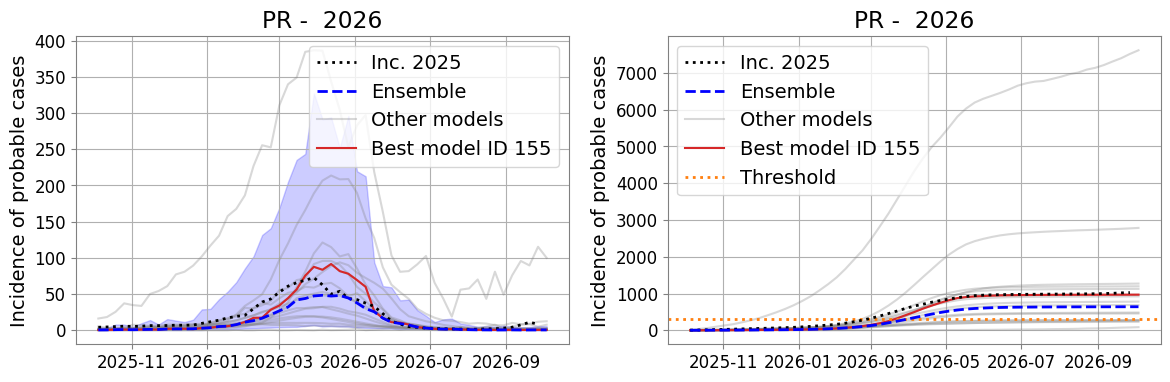

In [20]:
state = 'PR'
best_model = 155 

_, ax = plt.subplots(1,2, figsize = (14, 4))

make_comp_plot(ax[0], state, best_model, df_median_ens, df_for)
make_comp_plot(ax[1], state, best_model, df_median_ens, df_for, cumulative=True)


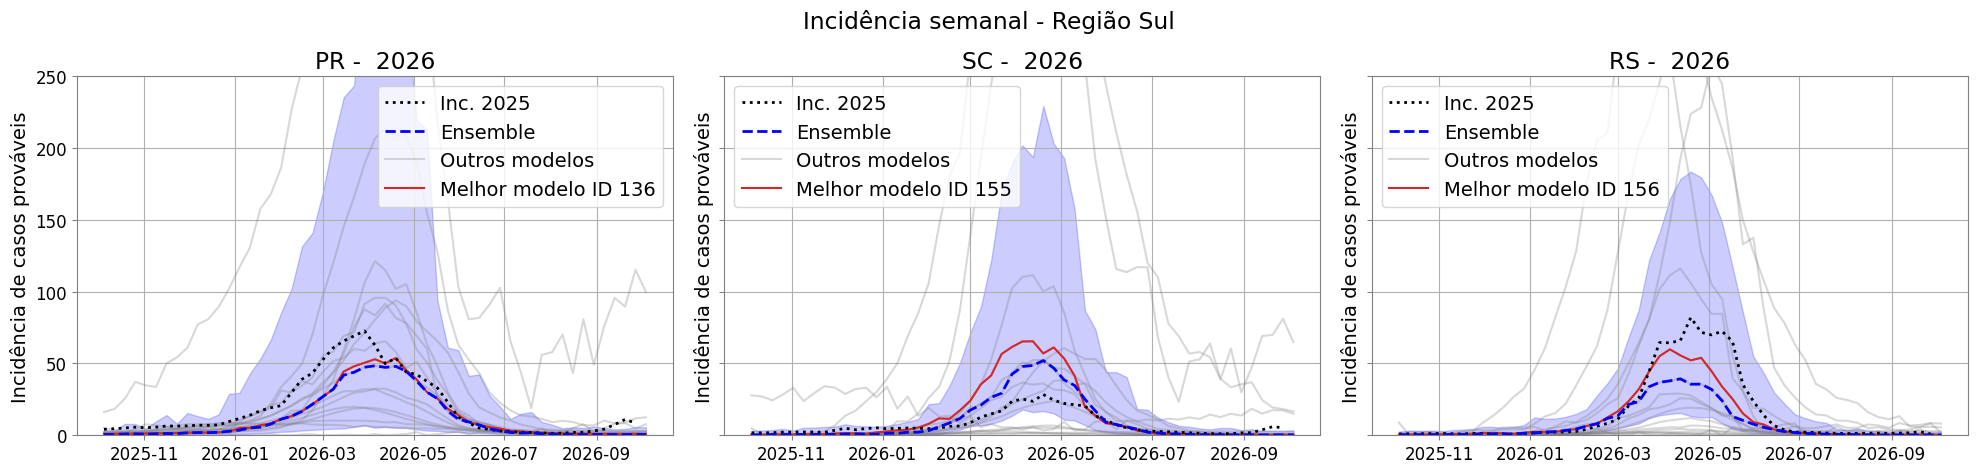

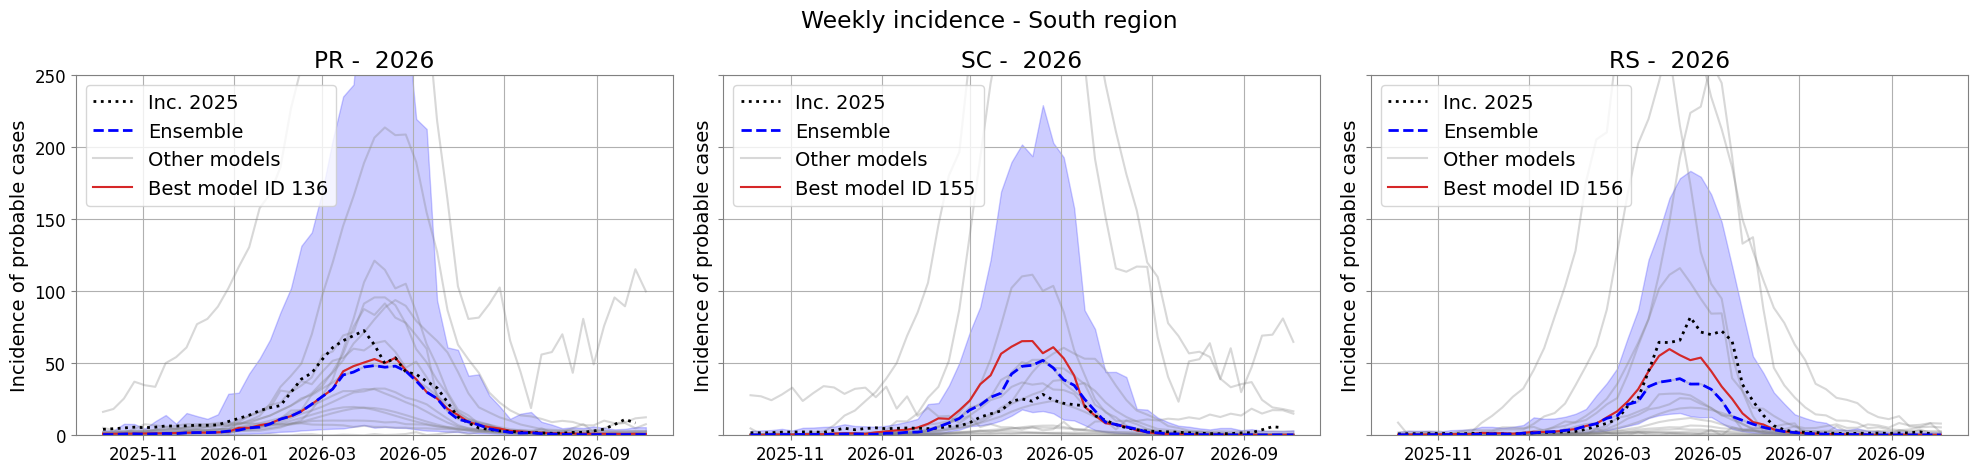

In [21]:
for language in ['pt', 'en']:
    _, ax = plt.subplots(1,3, figsize = (20, 5), sharey = True)

    for state, ax_ in zip(['PR', 'SC', 'RS'], ax.ravel()):
        
        best_model = df_bm.loc[df_bm.state == state]['best_model_norm'].values[0]
        #best_model = 136
        make_comp_plot(ax_, state, best_model, df_median_ens, df_for, cumulative=False, language=language)

    ax[0].set_ybound([0, 250])

    if language == 'pt': 
        plt.suptitle('Incidência semanal - Região Sul', y = 0.95)
    else: 
        plt.suptitle('Weekly incidence - South region', y = 0.95)

    plt.tight_layout()
    plt.savefig(f'figures/weekly_cases_sul_{language}.png', dpi = 400, bbox_inches = 'tight')
    plt.show()

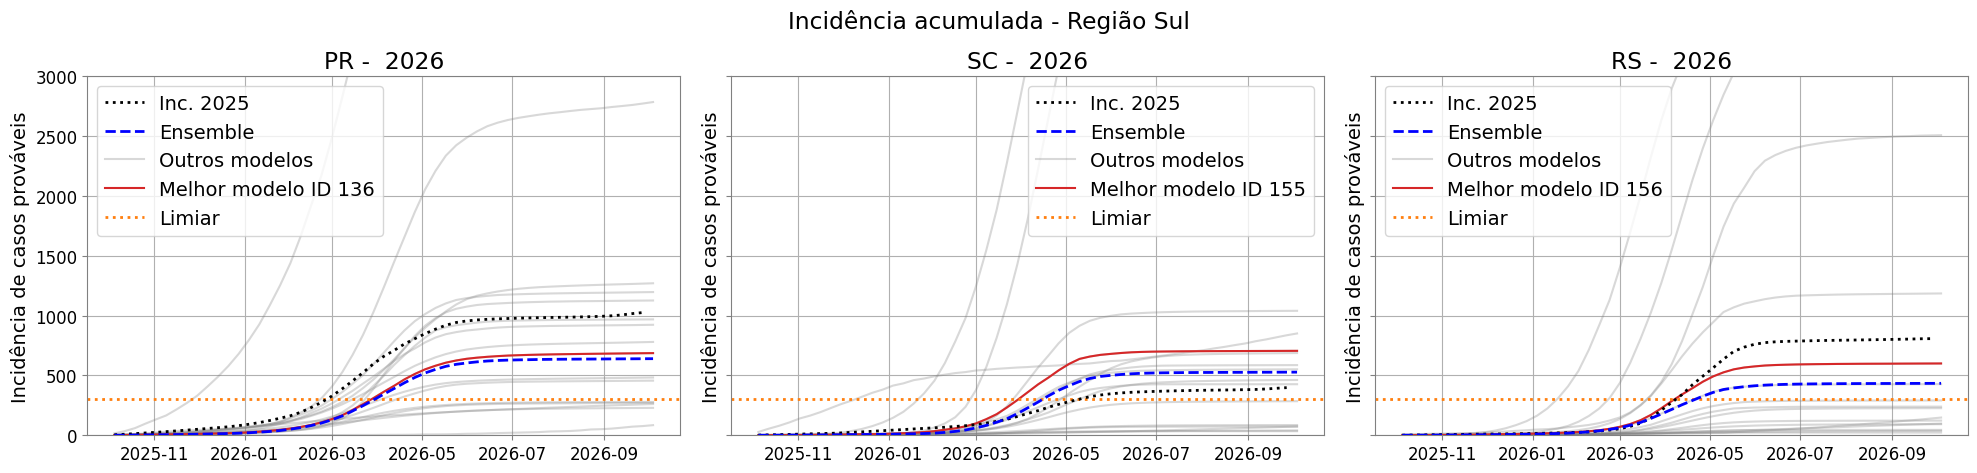

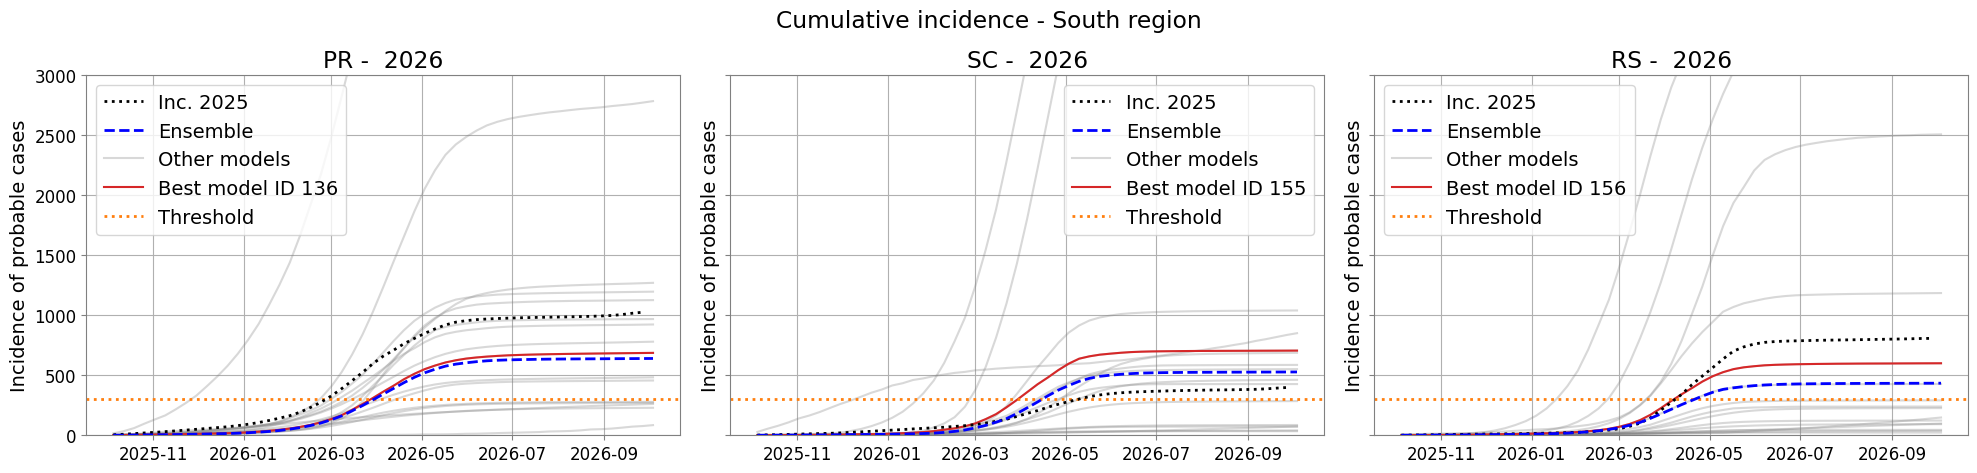

In [22]:
for language in ['pt', 'en']:

    _, ax = plt.subplots(1,3, figsize = (20, 5), sharey = True)

    for state, ax_ in zip(['PR', 'SC', 'RS'], ax.ravel()):
        
        best_model = df_bm.loc[df_bm.state == state]['best_model_norm'].values[0]
        #best_model = 133
        make_comp_plot(ax_, state, best_model, df_median_ens, df_for, cumulative=True, language=language)

    ax[0].set_ybound([0, 3000])


    if language == 'pt': 
        plt.suptitle('Incidência acumulada - Região Sul', y = 0.95)
    else: 
        plt.suptitle('Cumulative incidence - South region', y = 0.95)

    plt.tight_layout()
    plt.savefig(f'figures/cumulative_cases_sul_{language}.png', dpi = 400, bbox_inches = 'tight')
    plt.show()

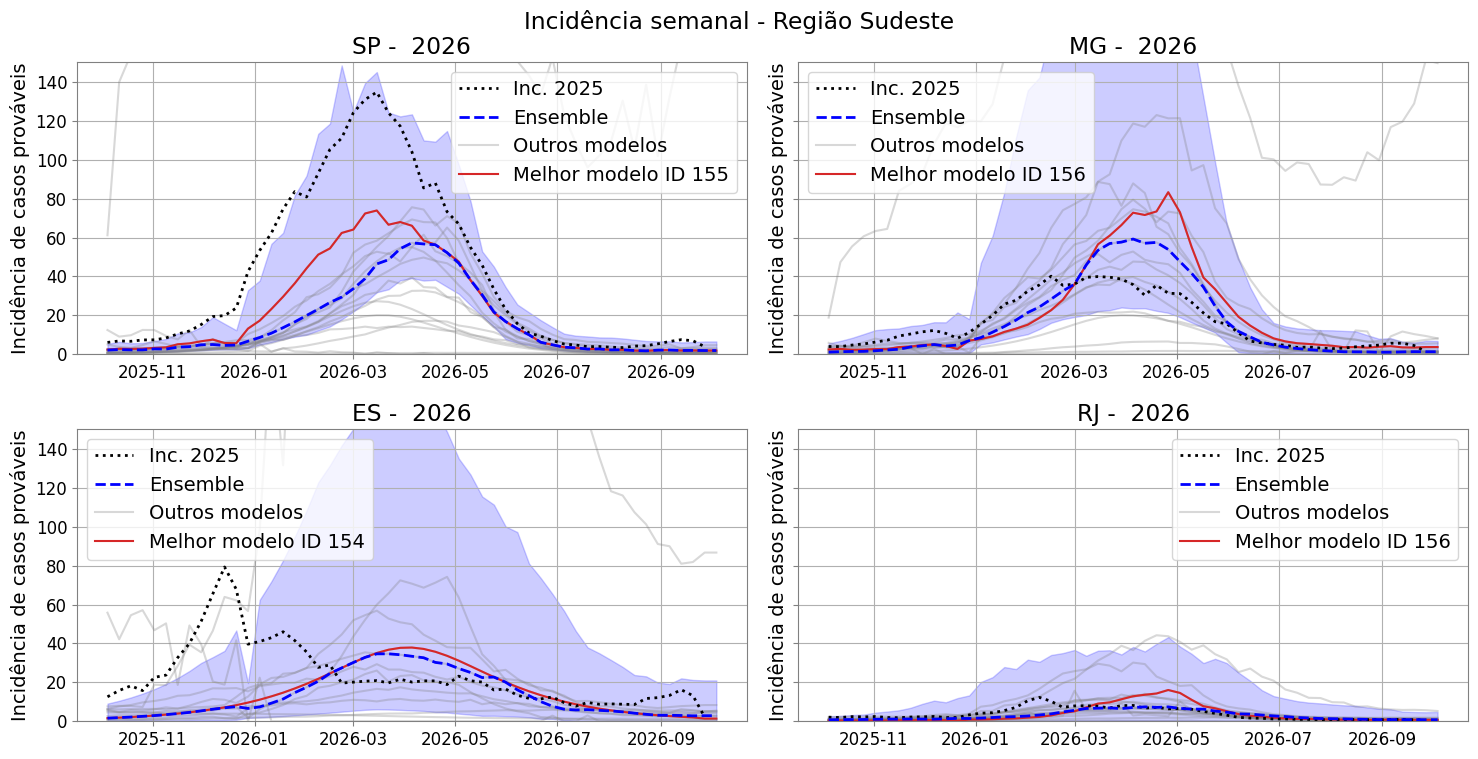

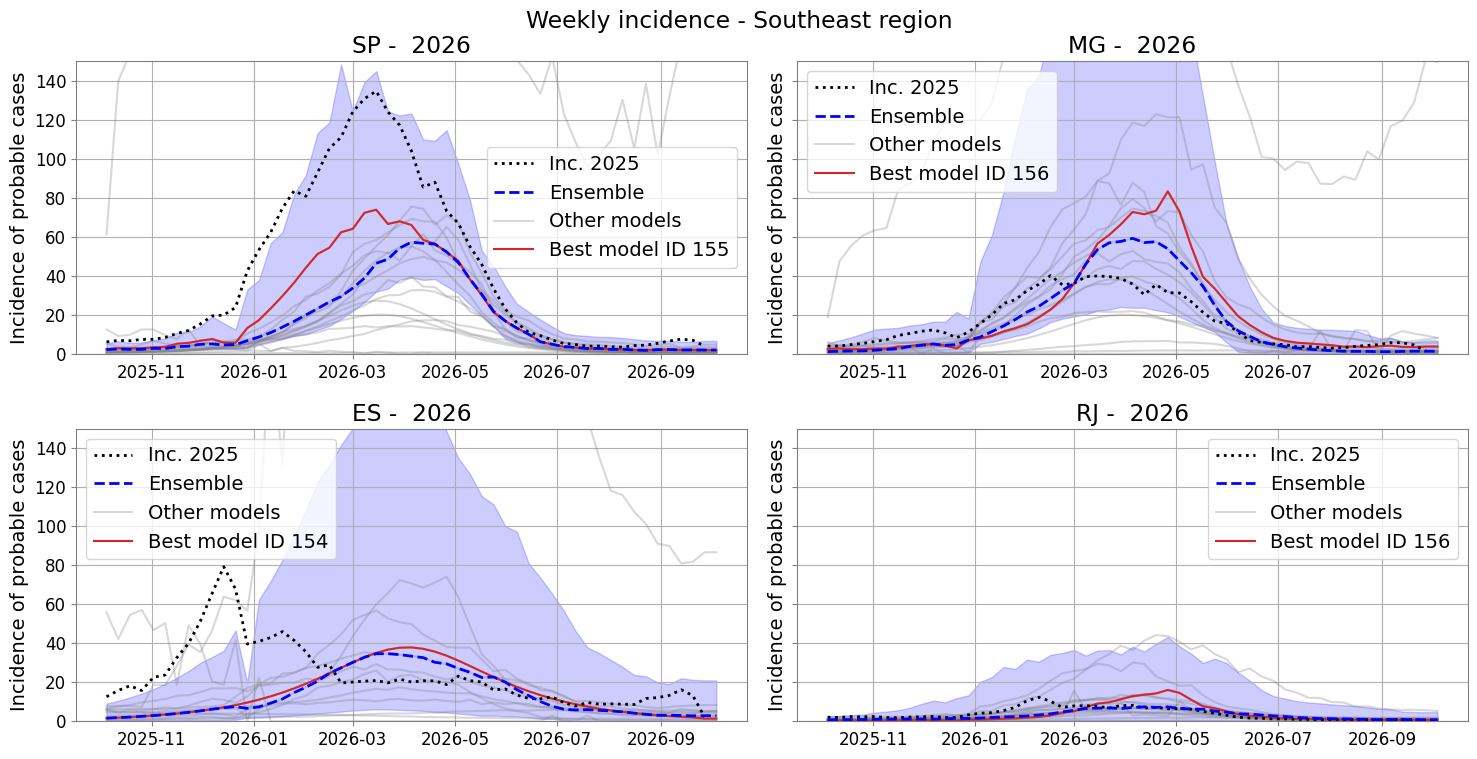

In [23]:
for language in ['pt', 'en']:

    _, ax = plt.subplots(2,2, figsize = (15, 8), sharey = True)

    for state, ax_ in zip(['SP', 'MG', 'ES', 'RJ'], ax.ravel()):
        
        best_model = df_bm.loc[df_bm.state == state]['best_model_norm'].values[0]
        #if state == 'ES':
        #    best_model = 155
        make_comp_plot(ax_, state, best_model, df_median_ens, df_for, cumulative=False, language=language)

    ax[0,0].set_ybound([0, 150])

    if language == 'pt': 
        plt.suptitle('Incidência semanal - Região Sudeste', y = 0.95)
    else: 
        plt.suptitle('Weekly incidence - Southeast region', y = 0.95)

    plt.tight_layout()
    plt.savefig(f'figures/weekly_cases_sudeste_{language}.png', dpi = 400, bbox_inches = 'tight')
    plt.show()
    

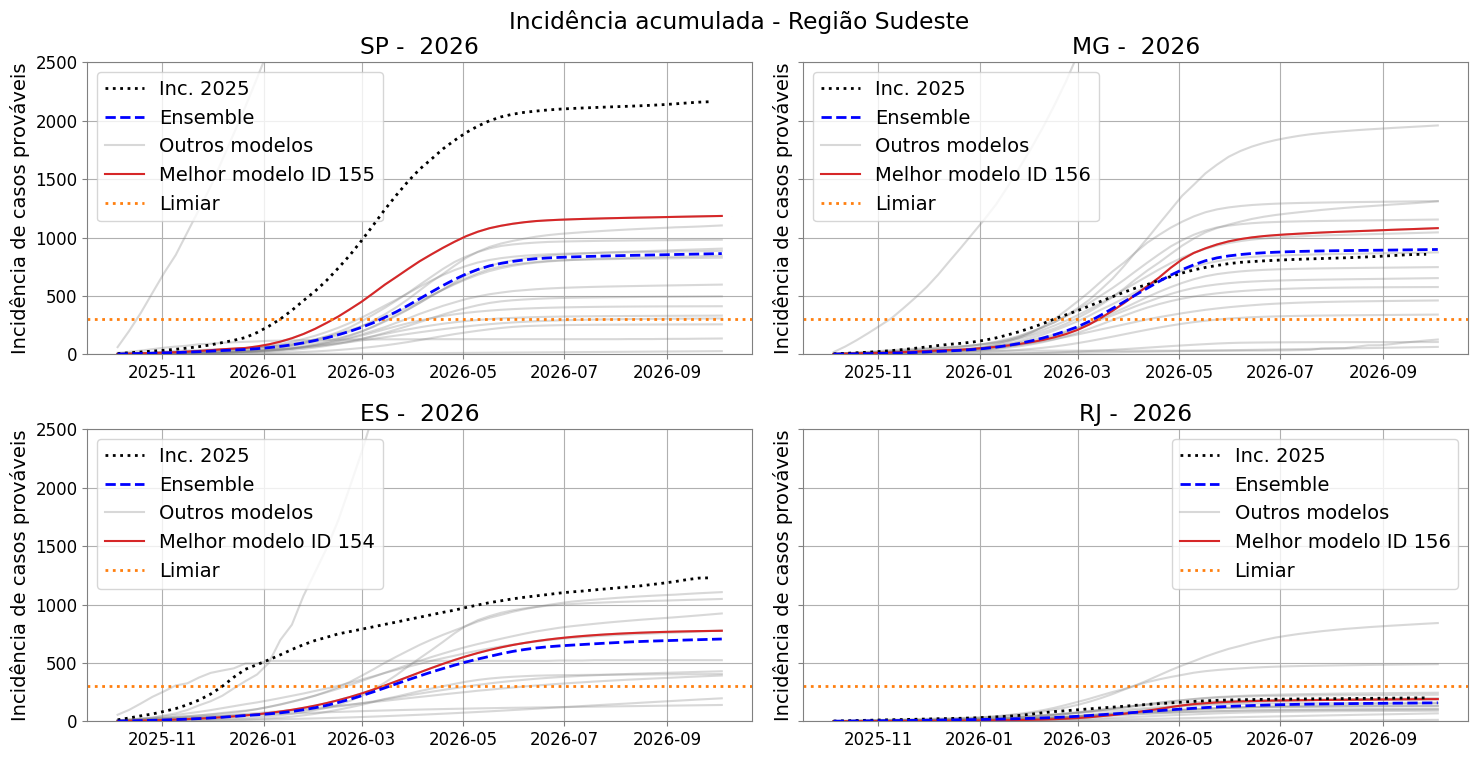

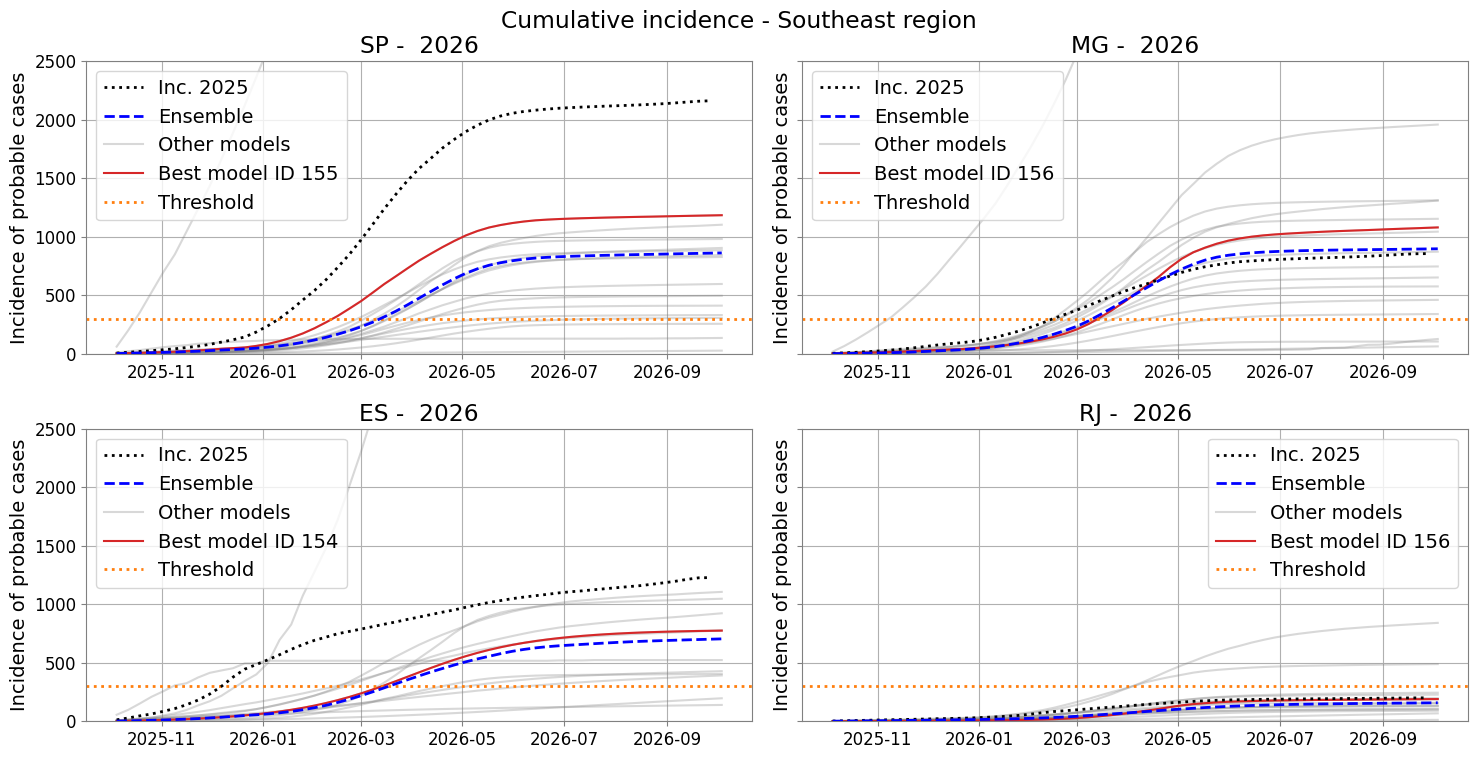

In [24]:
for language in ['pt', 'en']:
 
    _, ax = plt.subplots(2,2, figsize = (15, 8), sharey = True)

    for state, ax_ in zip(['SP', 'MG', 'ES', 'RJ'], ax.ravel()):
        
        best_model = df_bm.loc[df_bm.state == state]['best_model_norm'].values[0]

        make_comp_plot(ax_, state, best_model, df_median_ens, df_for, cumulative=True, language=language)

    ax[0,0].set_ybound([0, 2500])

    if language == 'pt': 
        plt.suptitle('Incidência acumulada - Região Sudeste', y = 0.95)
    else: 
        plt.suptitle('Cumulative incidence - Southeast region', y = 0.95)
    
    plt.tight_layout()
    plt.savefig(f'figures/cumulative_cases_sudeste_{language}.png', dpi = 400, bbox_inches = 'tight')
    plt.show()

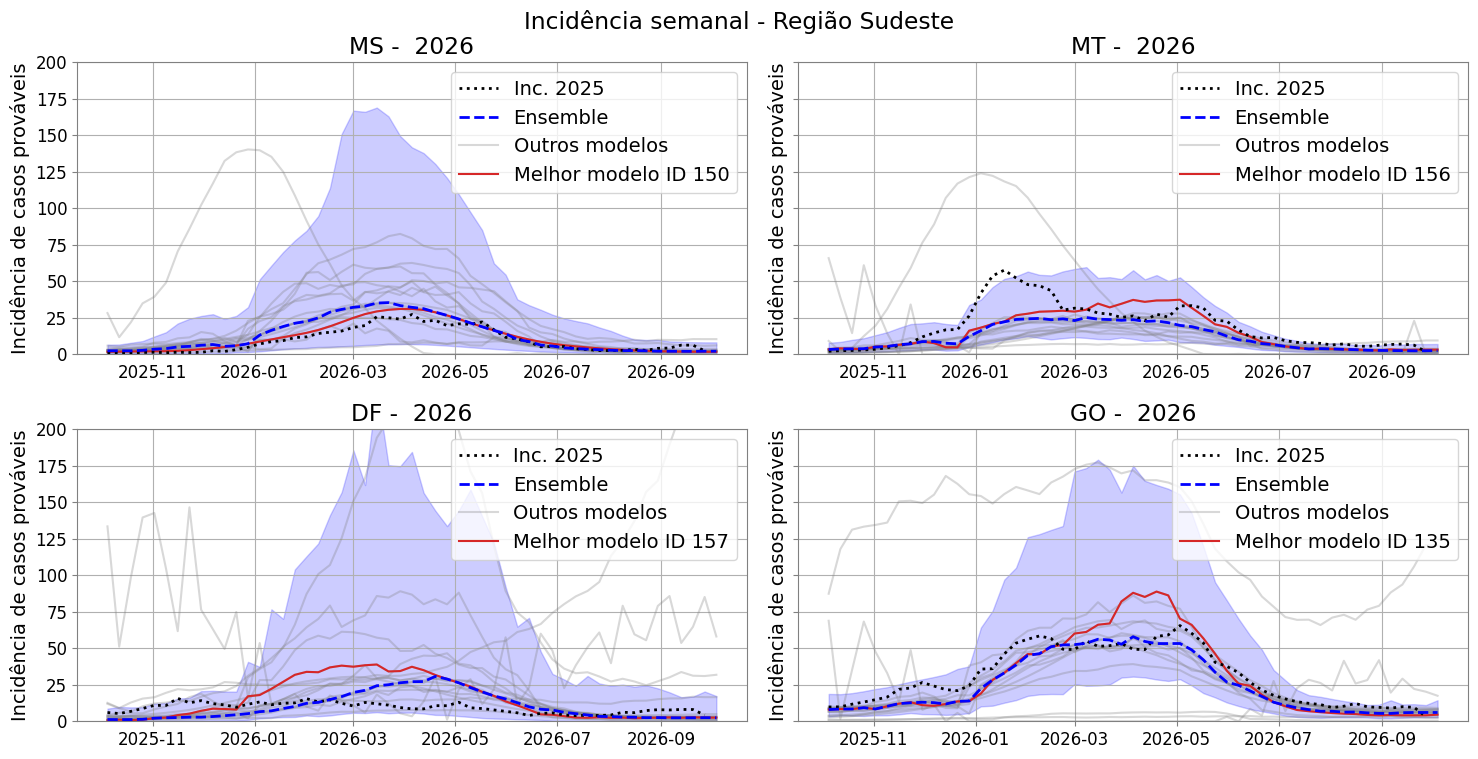

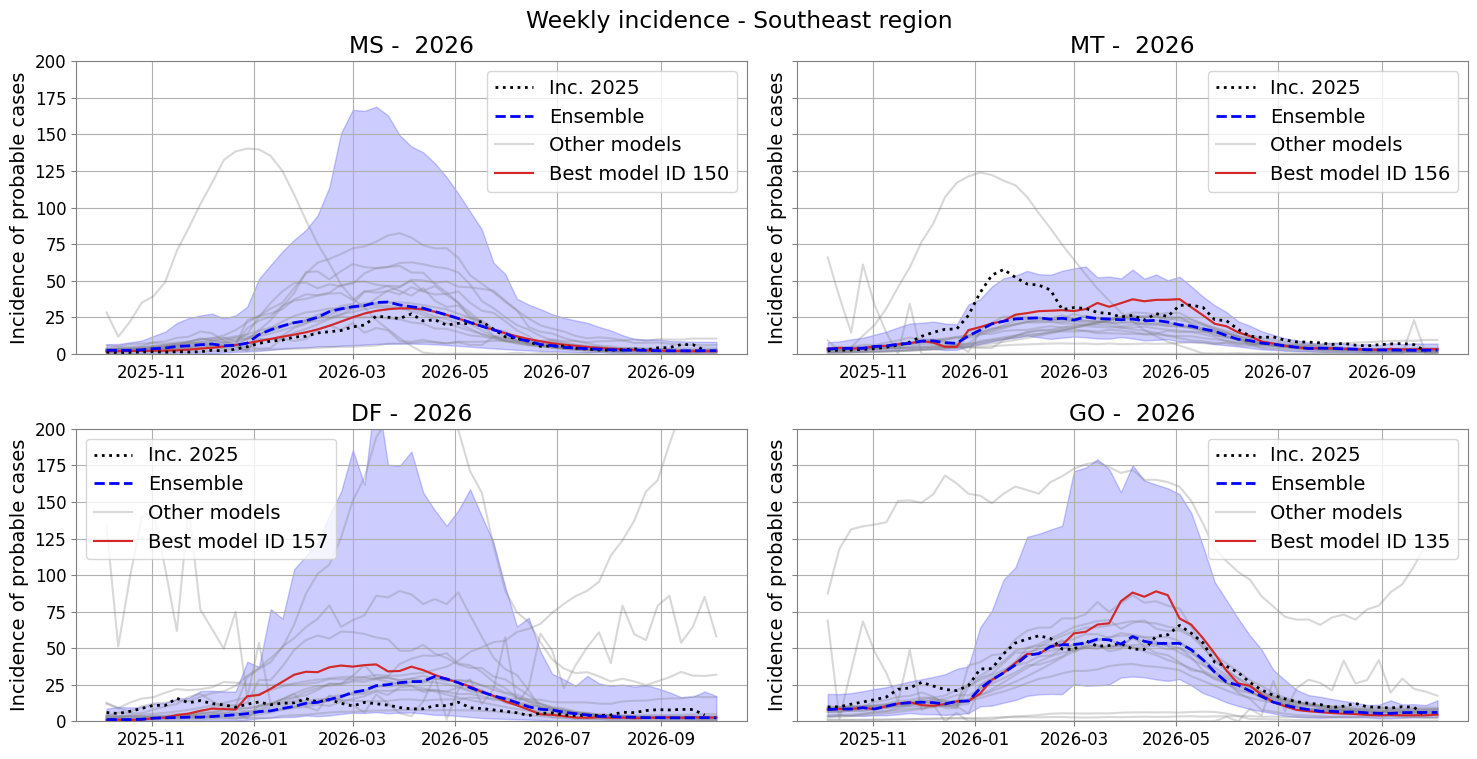

In [25]:
for language in ['pt', 'en']:
 
    _, ax = plt.subplots(2,2, figsize = (15, 8), sharey = True)

    for state, ax_ in zip(['MS', 'MT', 'DF', 'GO'], ax.ravel()):
        
        best_model = df_bm.loc[df_bm.state == state]['best_model_norm'].values[0]

        make_comp_plot(ax_, state, best_model, df_median_ens, df_for, cumulative=False, language=language)

    ax[0,0].set_ybound([0, 200])

    if language == 'pt': 
        plt.suptitle('Incidência semanal - Região Sudeste', y = 0.95)
    else: 
        plt.suptitle('Weekly incidence - Southeast region', y = 0.95)

    plt.tight_layout()
    plt.savefig(f'figures/weekly_cases_centro_oeste_{language}.png', dpi = 400, bbox_inches = 'tight')
    plt.show()

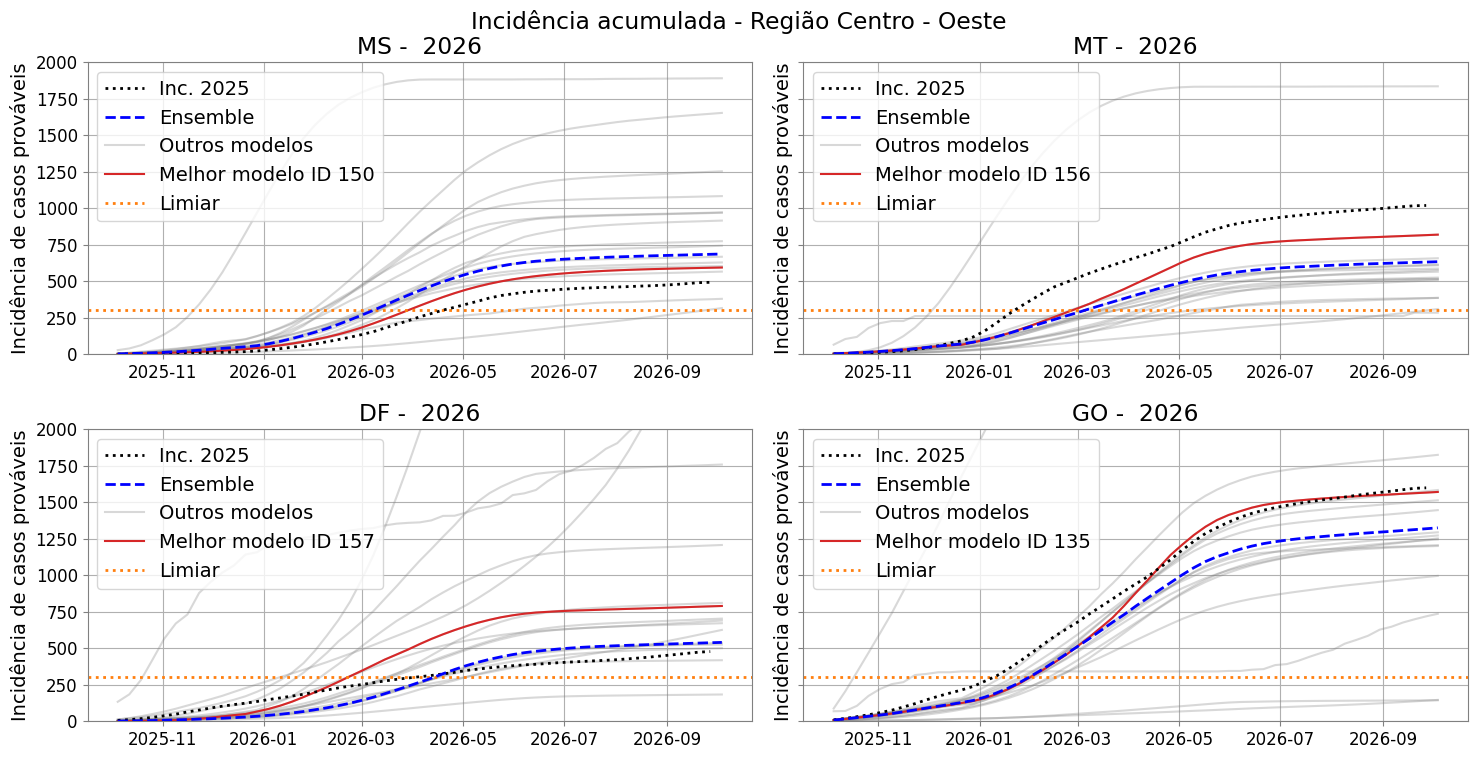

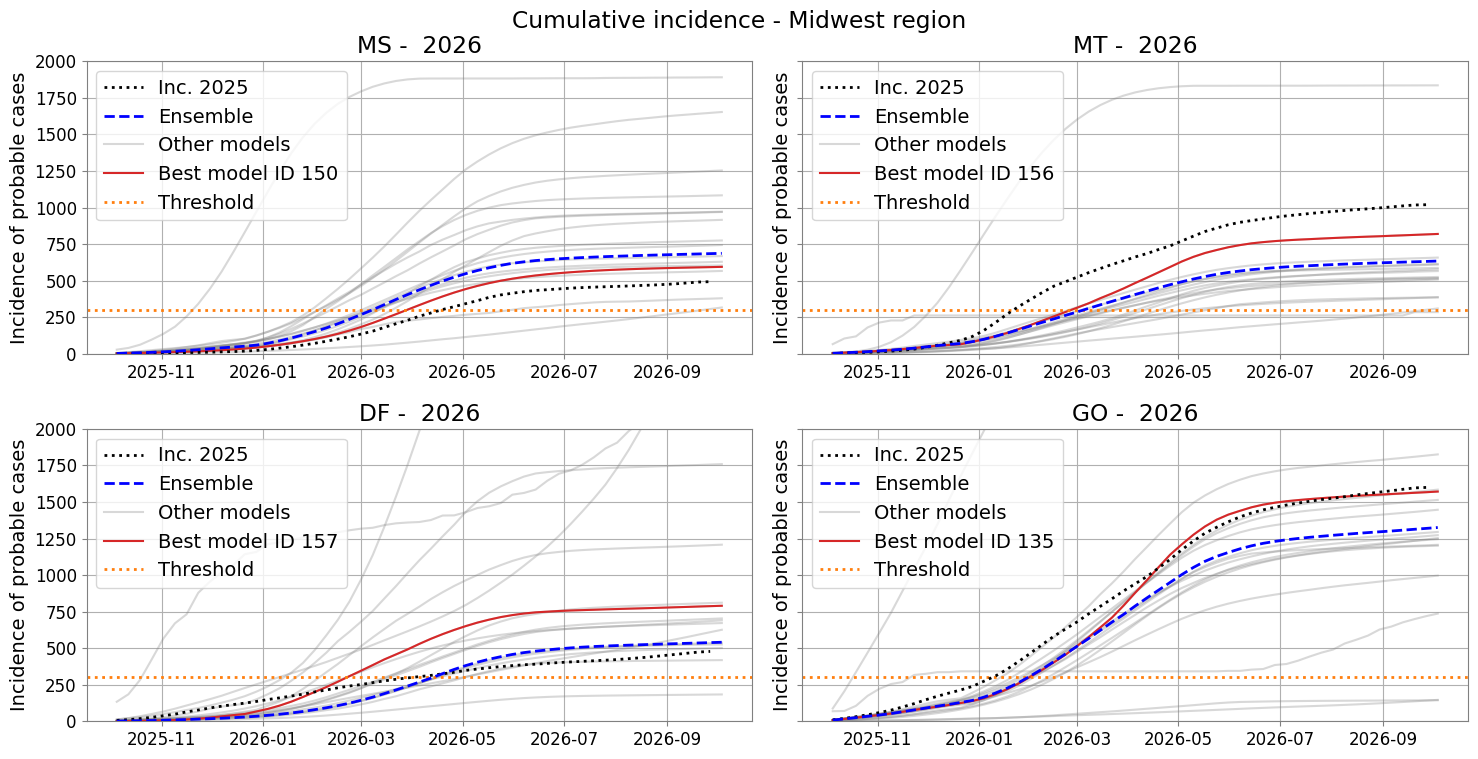

In [26]:
for language in ['pt', 'en']:

    _, ax = plt.subplots(2,2, figsize = (15, 8), sharey = True)

    for state, ax_ in zip(['MS', 'MT', 'DF', 'GO'], ax.ravel()):
        
        best_model = df_bm.loc[df_bm.state == state]['best_model_norm'].values[0]

        make_comp_plot(ax_, state, best_model, df_median_ens, df_for, cumulative=True, language=language)

    ax[0,0].set_ybound([0, 2000])

    if language == 'pt': 
        plt.suptitle('Incidência acumulada - Região Centro - Oeste', y = 0.95)
    else: 
        plt.suptitle('Cumulative incidence - Midwest region', y = 0.95)
    
    plt.tight_layout()
    plt.savefig(f'figures/cumulative_cases_centro_oeste_{language}.png', dpi = 400, bbox_inches = 'tight')
    plt.show()

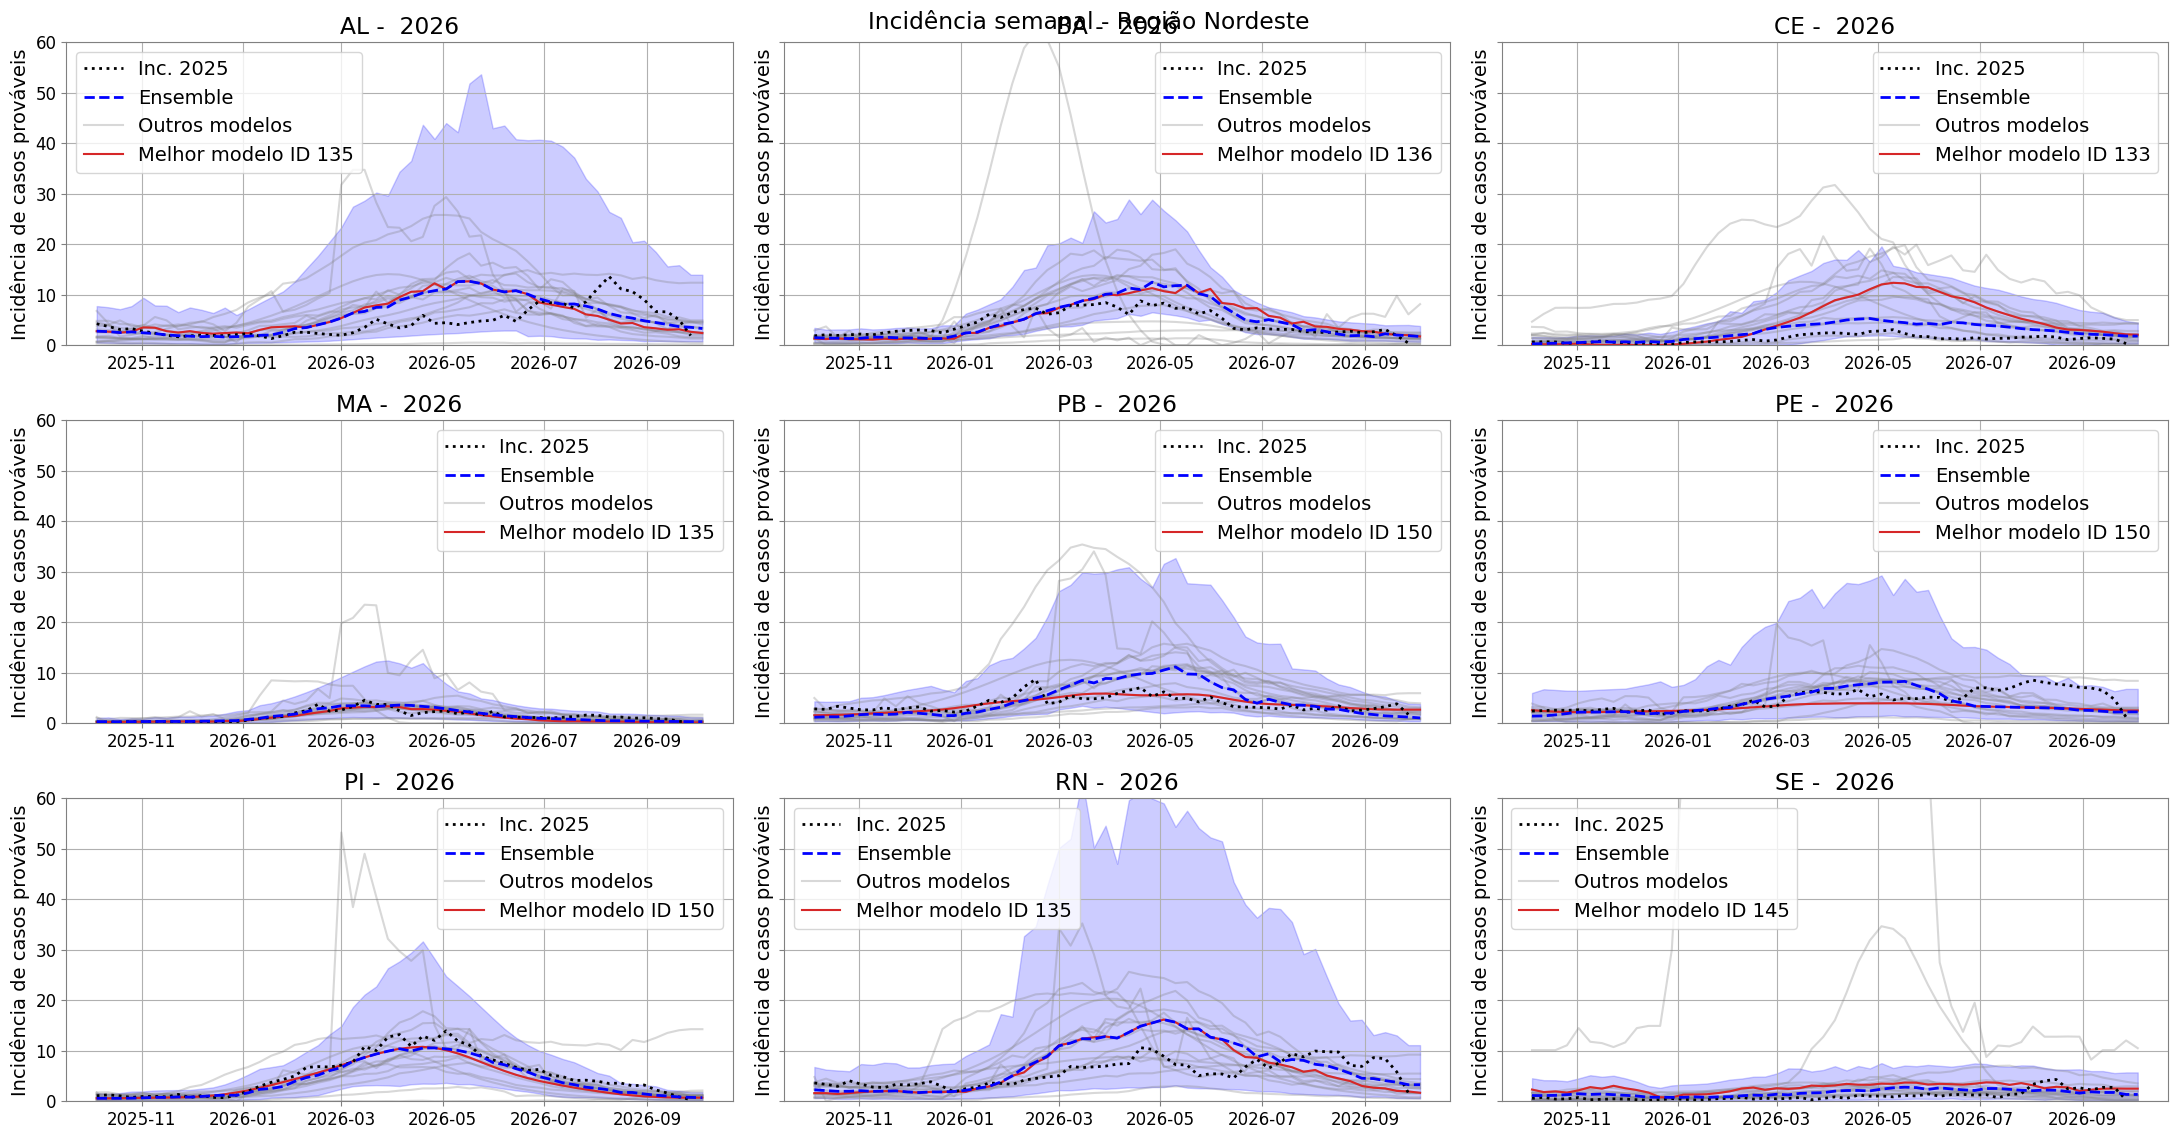

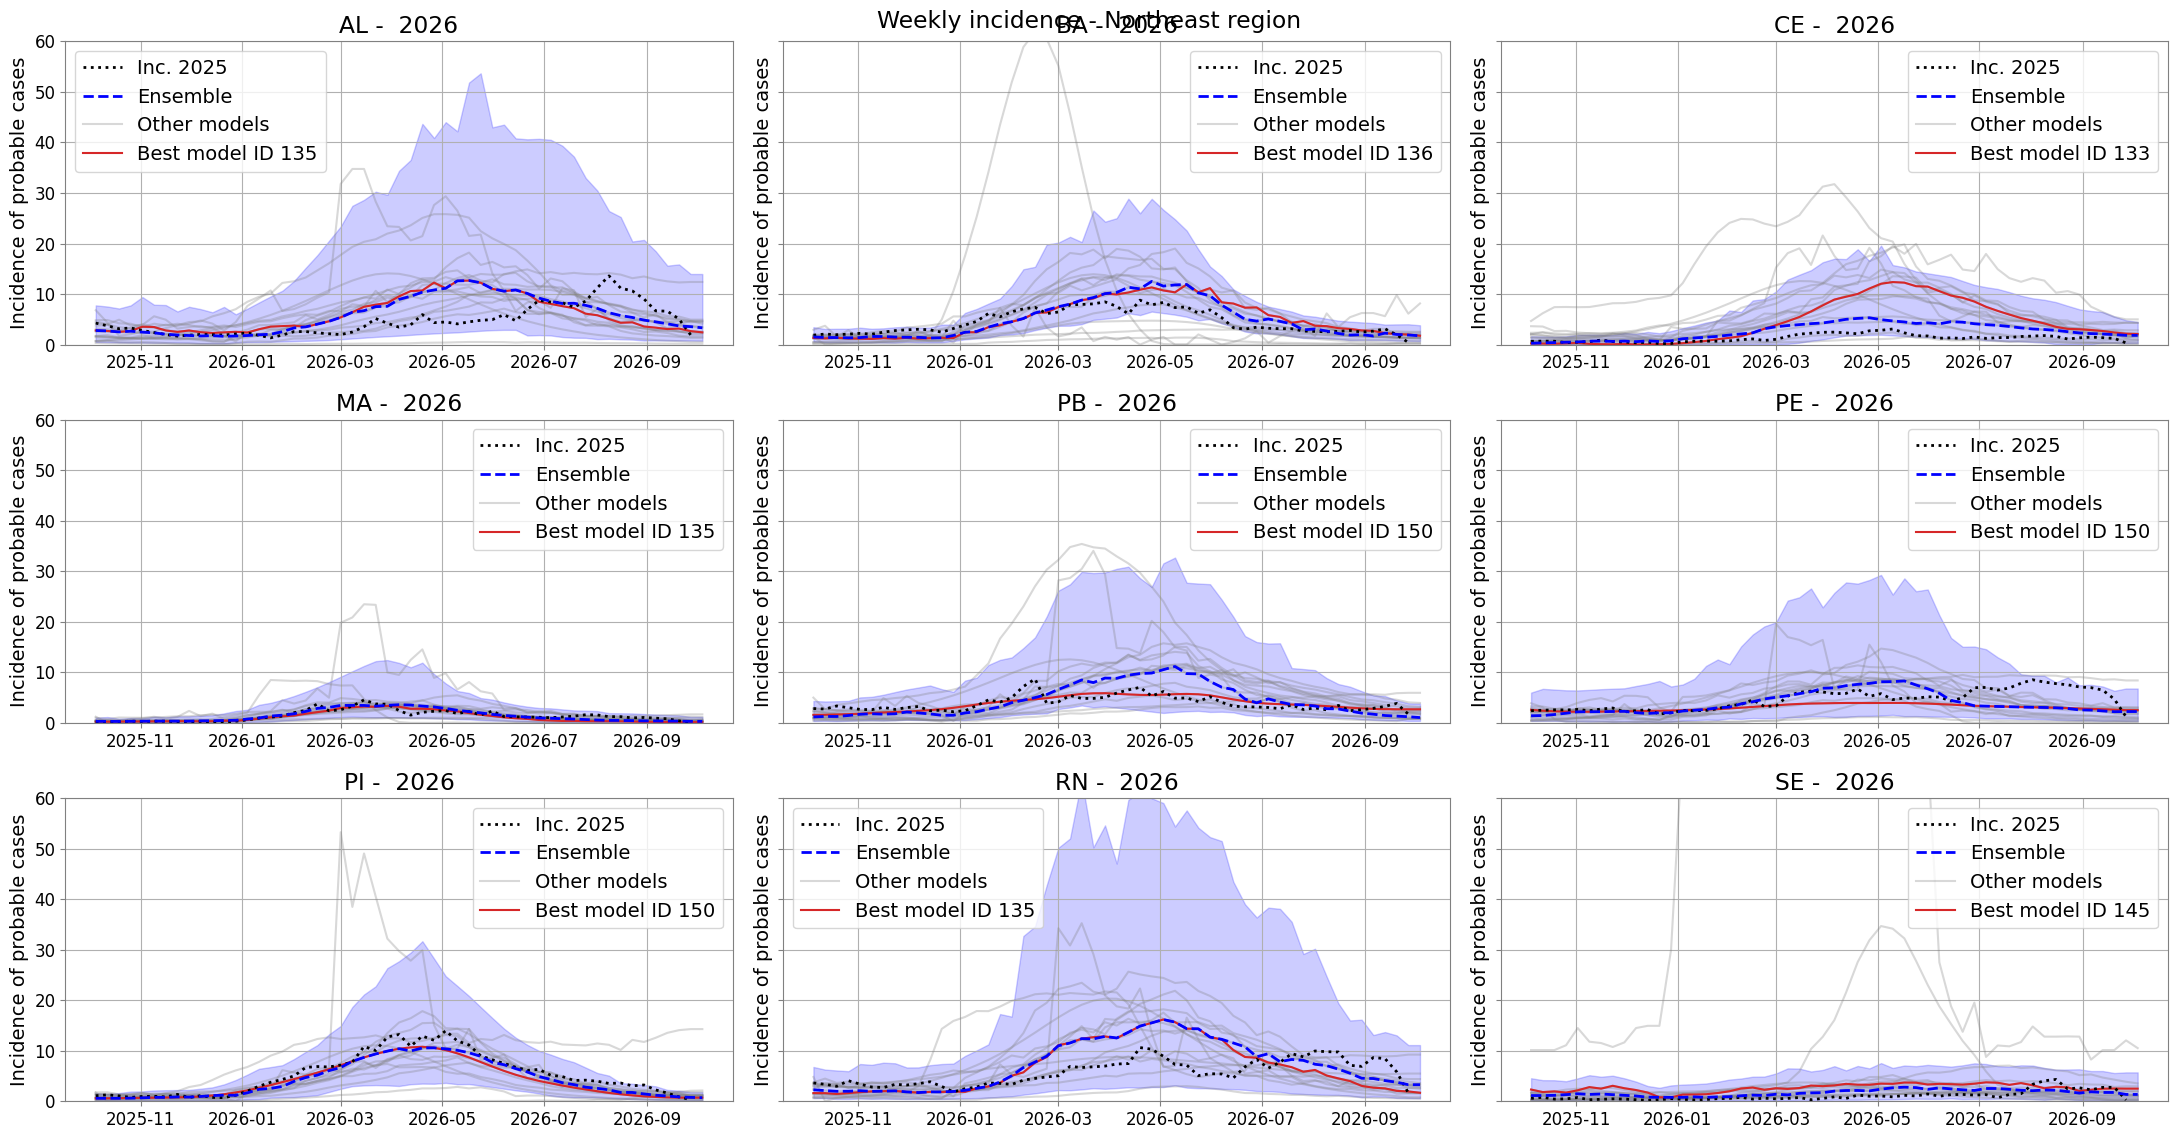

In [27]:
for language in ['pt', 'en']:
    
    _, ax = plt.subplots(3,3, figsize = (22, 12), sharey = True)

    for state, ax_ in zip(['AL', 'BA', 'CE', 'MA', 'PB', 'PE', 'PI', 'RN', 'SE'], ax.ravel()):
        
        best_model = df_bm.loc[df_bm.state == state]['best_model_norm'].values[0]
        make_comp_plot(ax_, state, best_model, df_median_ens, df_for, cumulative=False, language=language)

    ax[0,0].set_ybound([0, 60])

    if language == 'pt': 
        plt.suptitle('Incidência semanal - Região Nordeste', y = 0.95)
    else: 
        plt.suptitle('Weekly incidence - Northeast region', y = 0.95)


    plt.tight_layout()
    plt.savefig(f'figures/weekly_cases_nordeste_{language}.png', dpi = 400, bbox_inches = 'tight')
    plt.show()

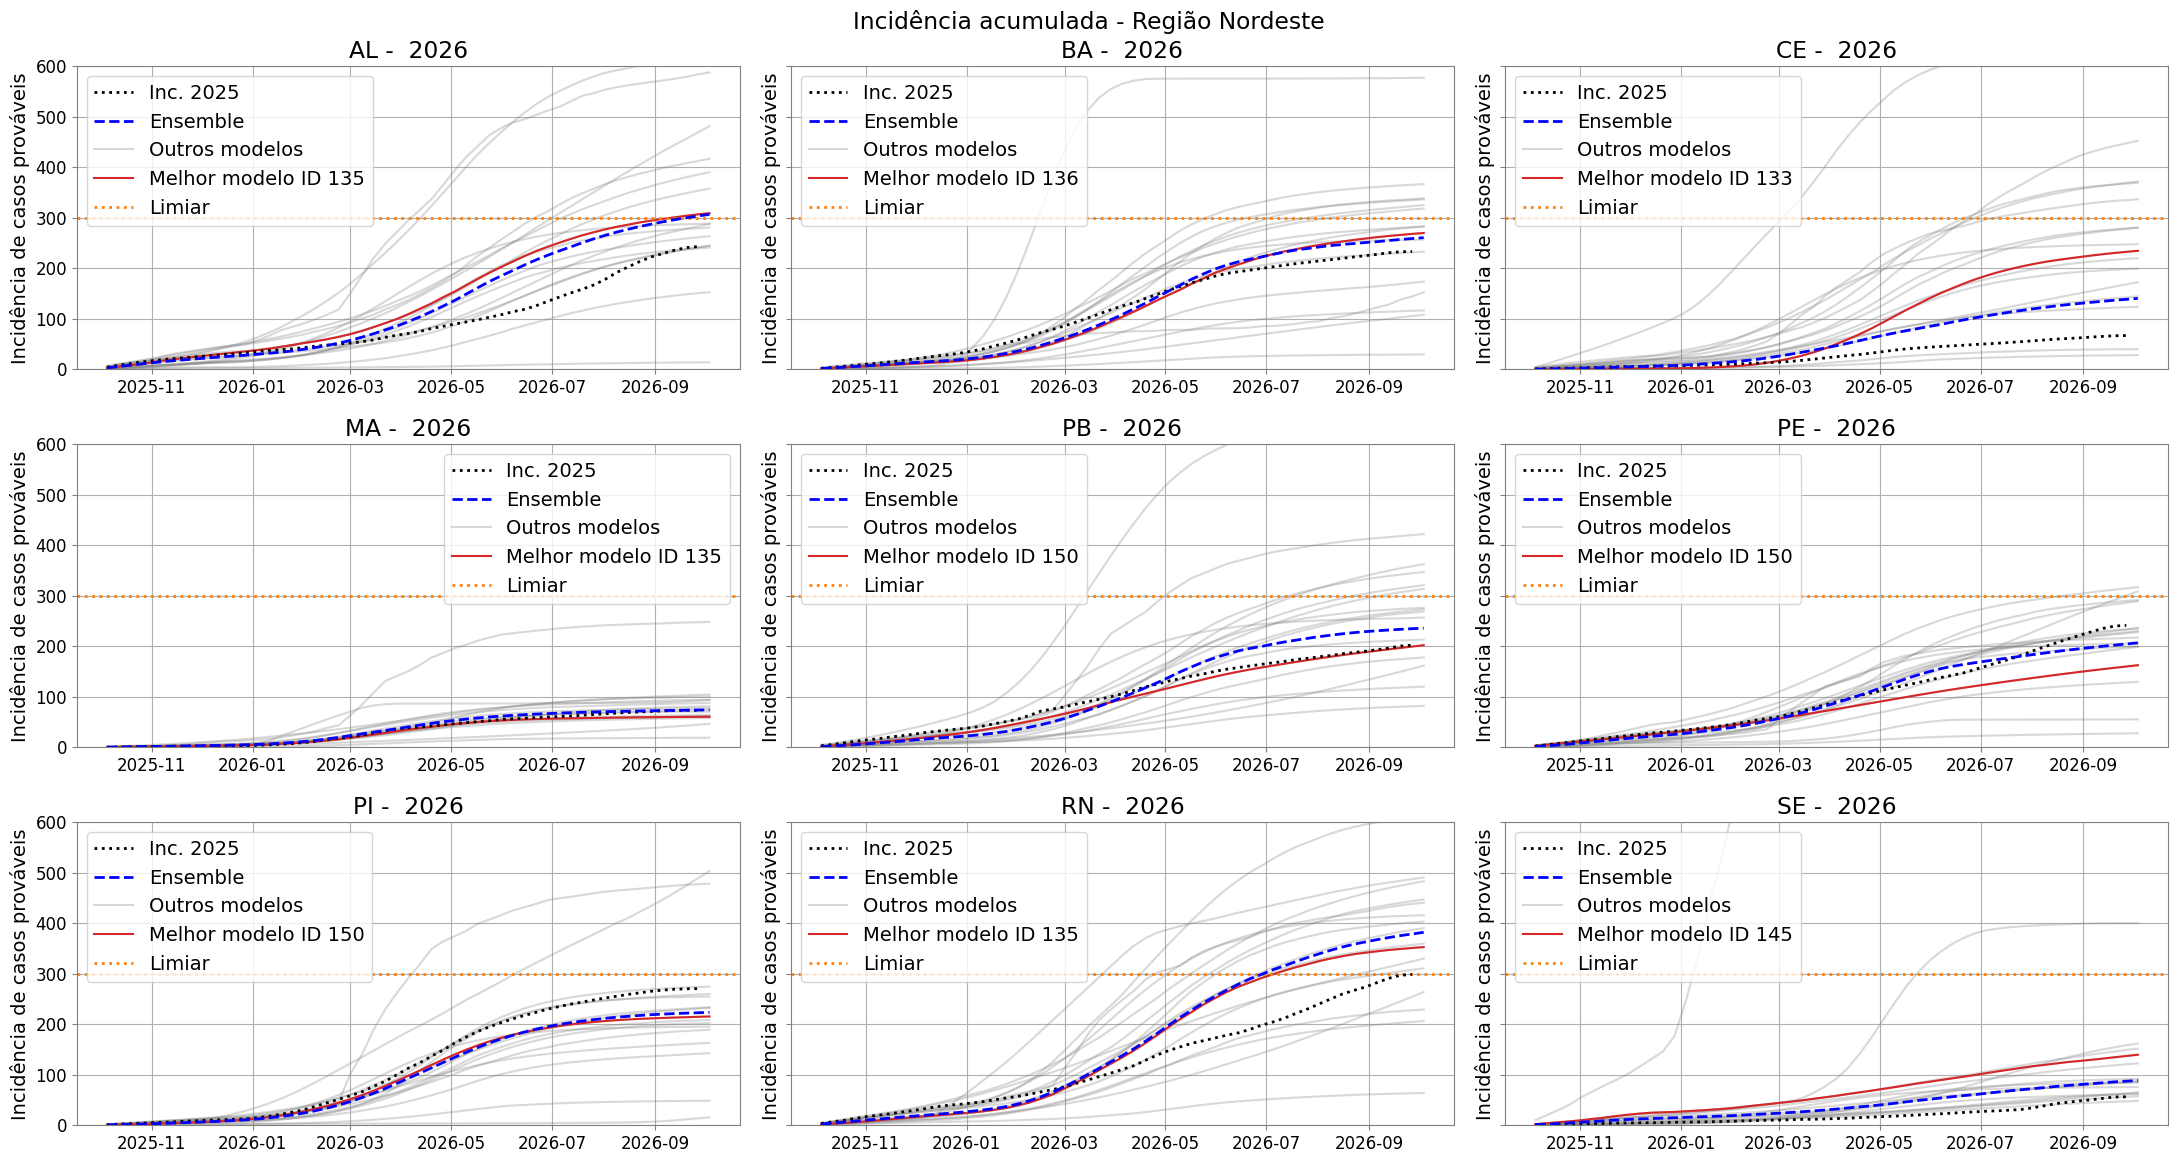

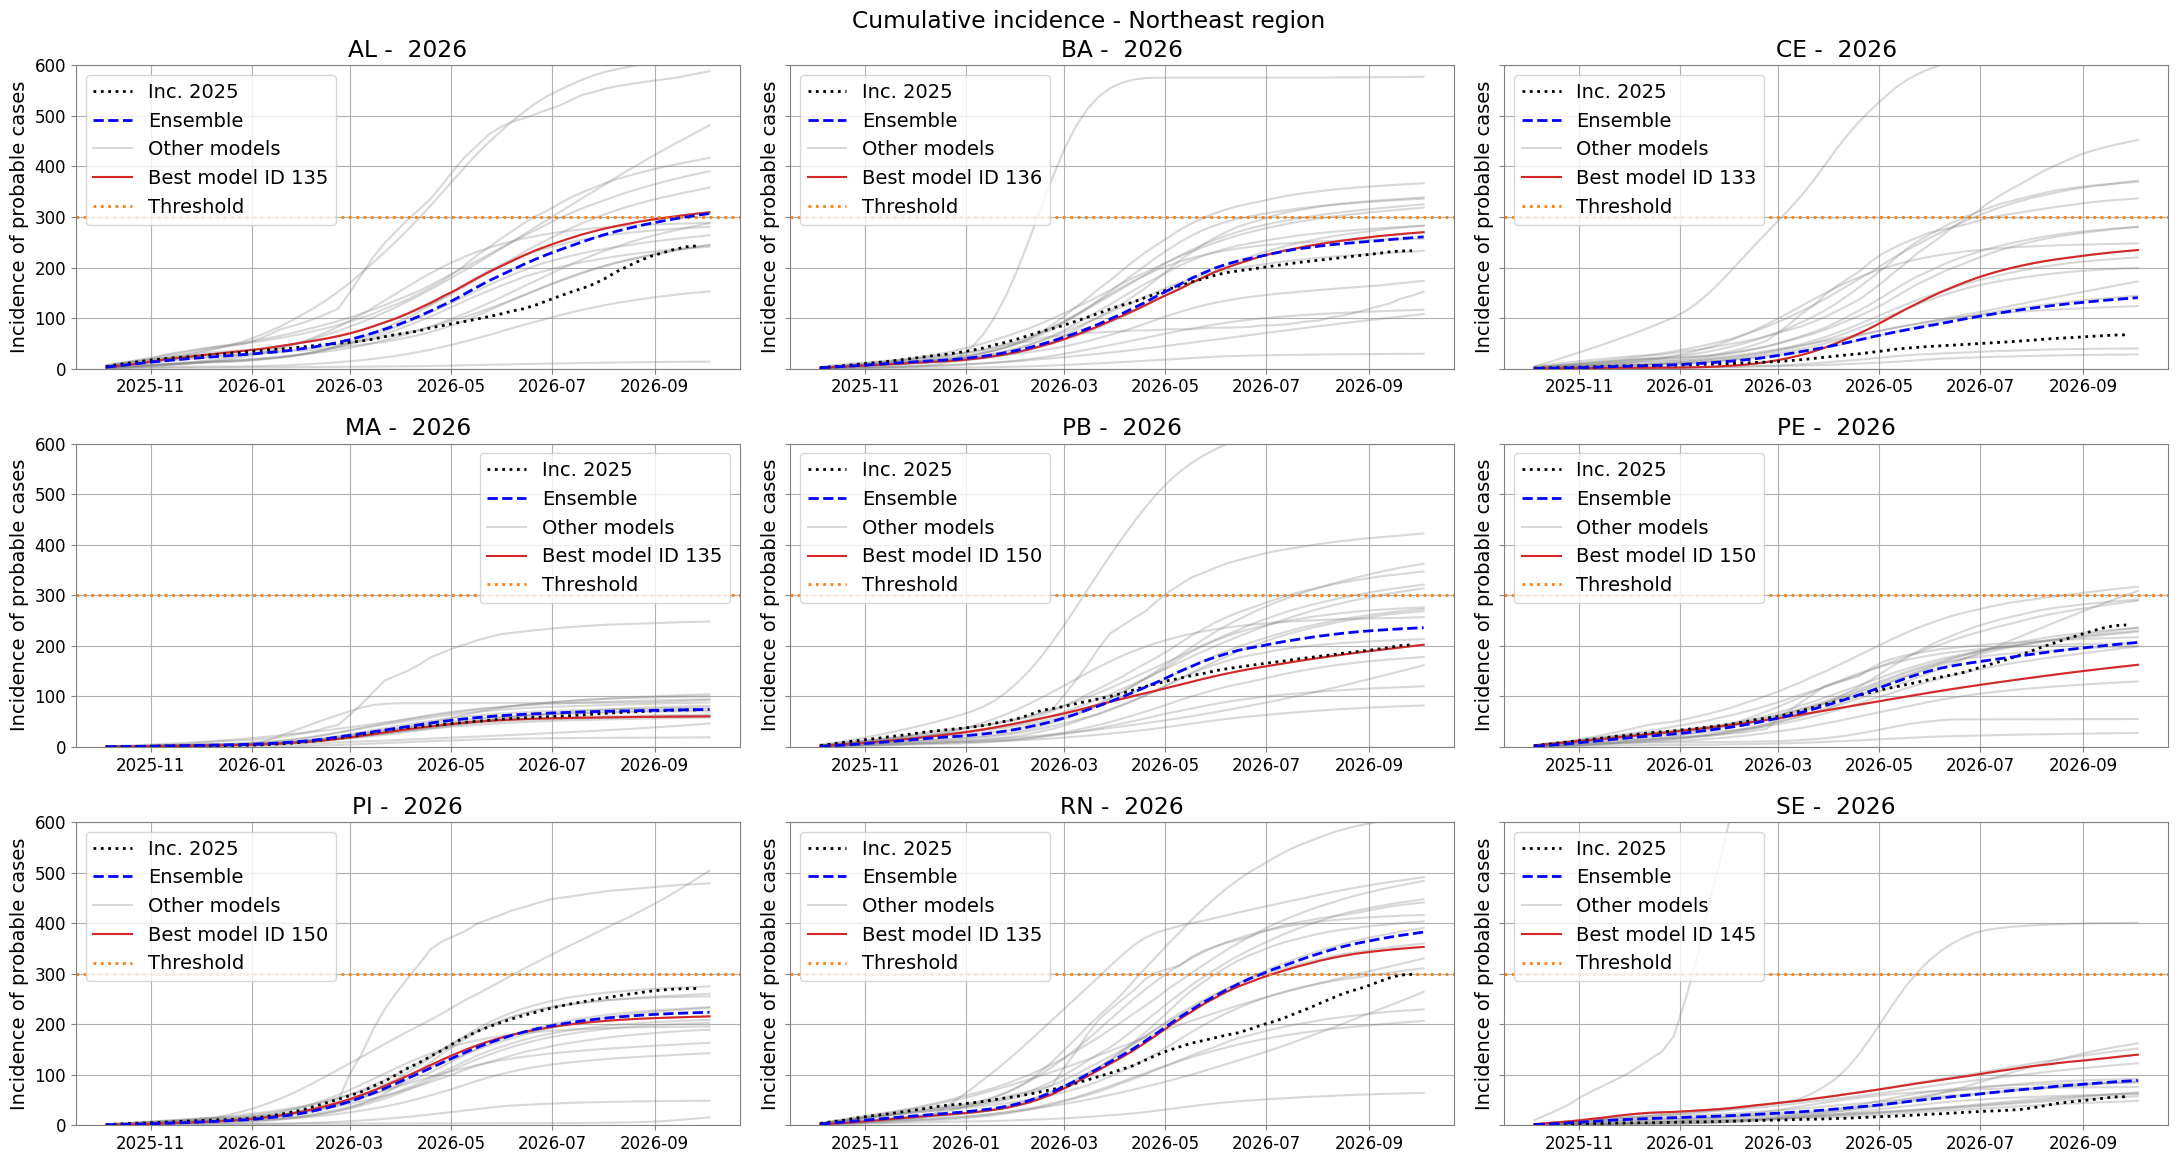

In [28]:
for language in ['pt', 'en']:
    
    _, ax = plt.subplots(3,3, figsize = (22, 12), sharey = True)

    for state, ax_ in zip(['AL', 'BA', 'CE', 'MA', 'PB', 'PE', 'PI', 'RN', 'SE'], ax.ravel()):
        
        best_model = df_bm.loc[df_bm.state == state]['best_model_norm'].values[0]
        make_comp_plot(ax_, state, best_model, df_median_ens, df_for, cumulative=True, language=language)

    ax[0,0].set_ybound([0, 600])

    if language == 'pt': 
        plt.suptitle('Incidência acumulada - Região Nordeste', y = 0.97)
    else: 
        plt.suptitle('Cumulative incidence - Northeast region', y = 0.97)
    
    plt.tight_layout()
    plt.savefig(f'figures/cumulative_cases_nordeste_{language}.png', dpi = 400, bbox_inches = 'tight')
    plt.show()

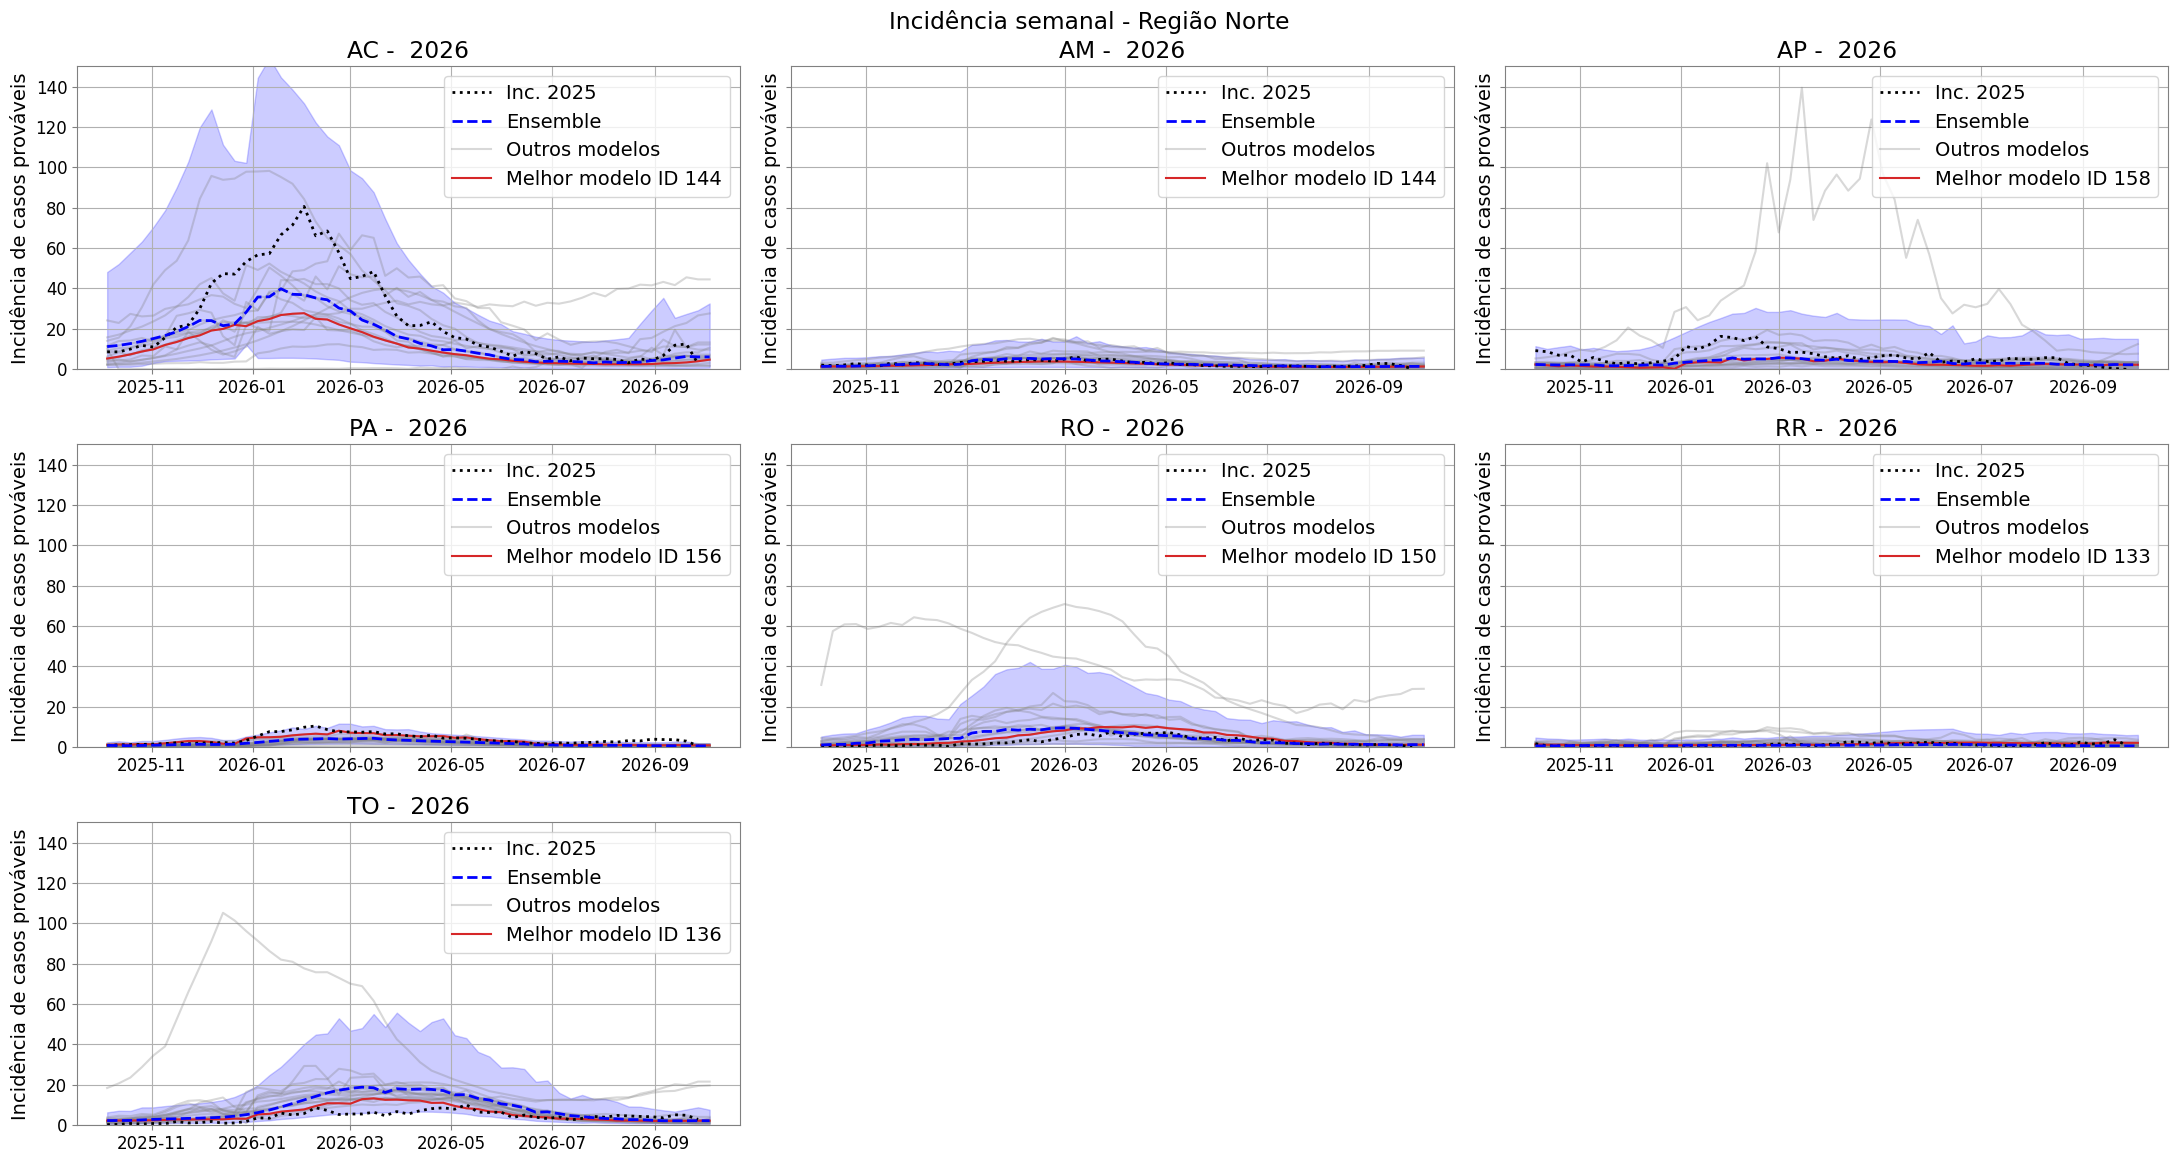

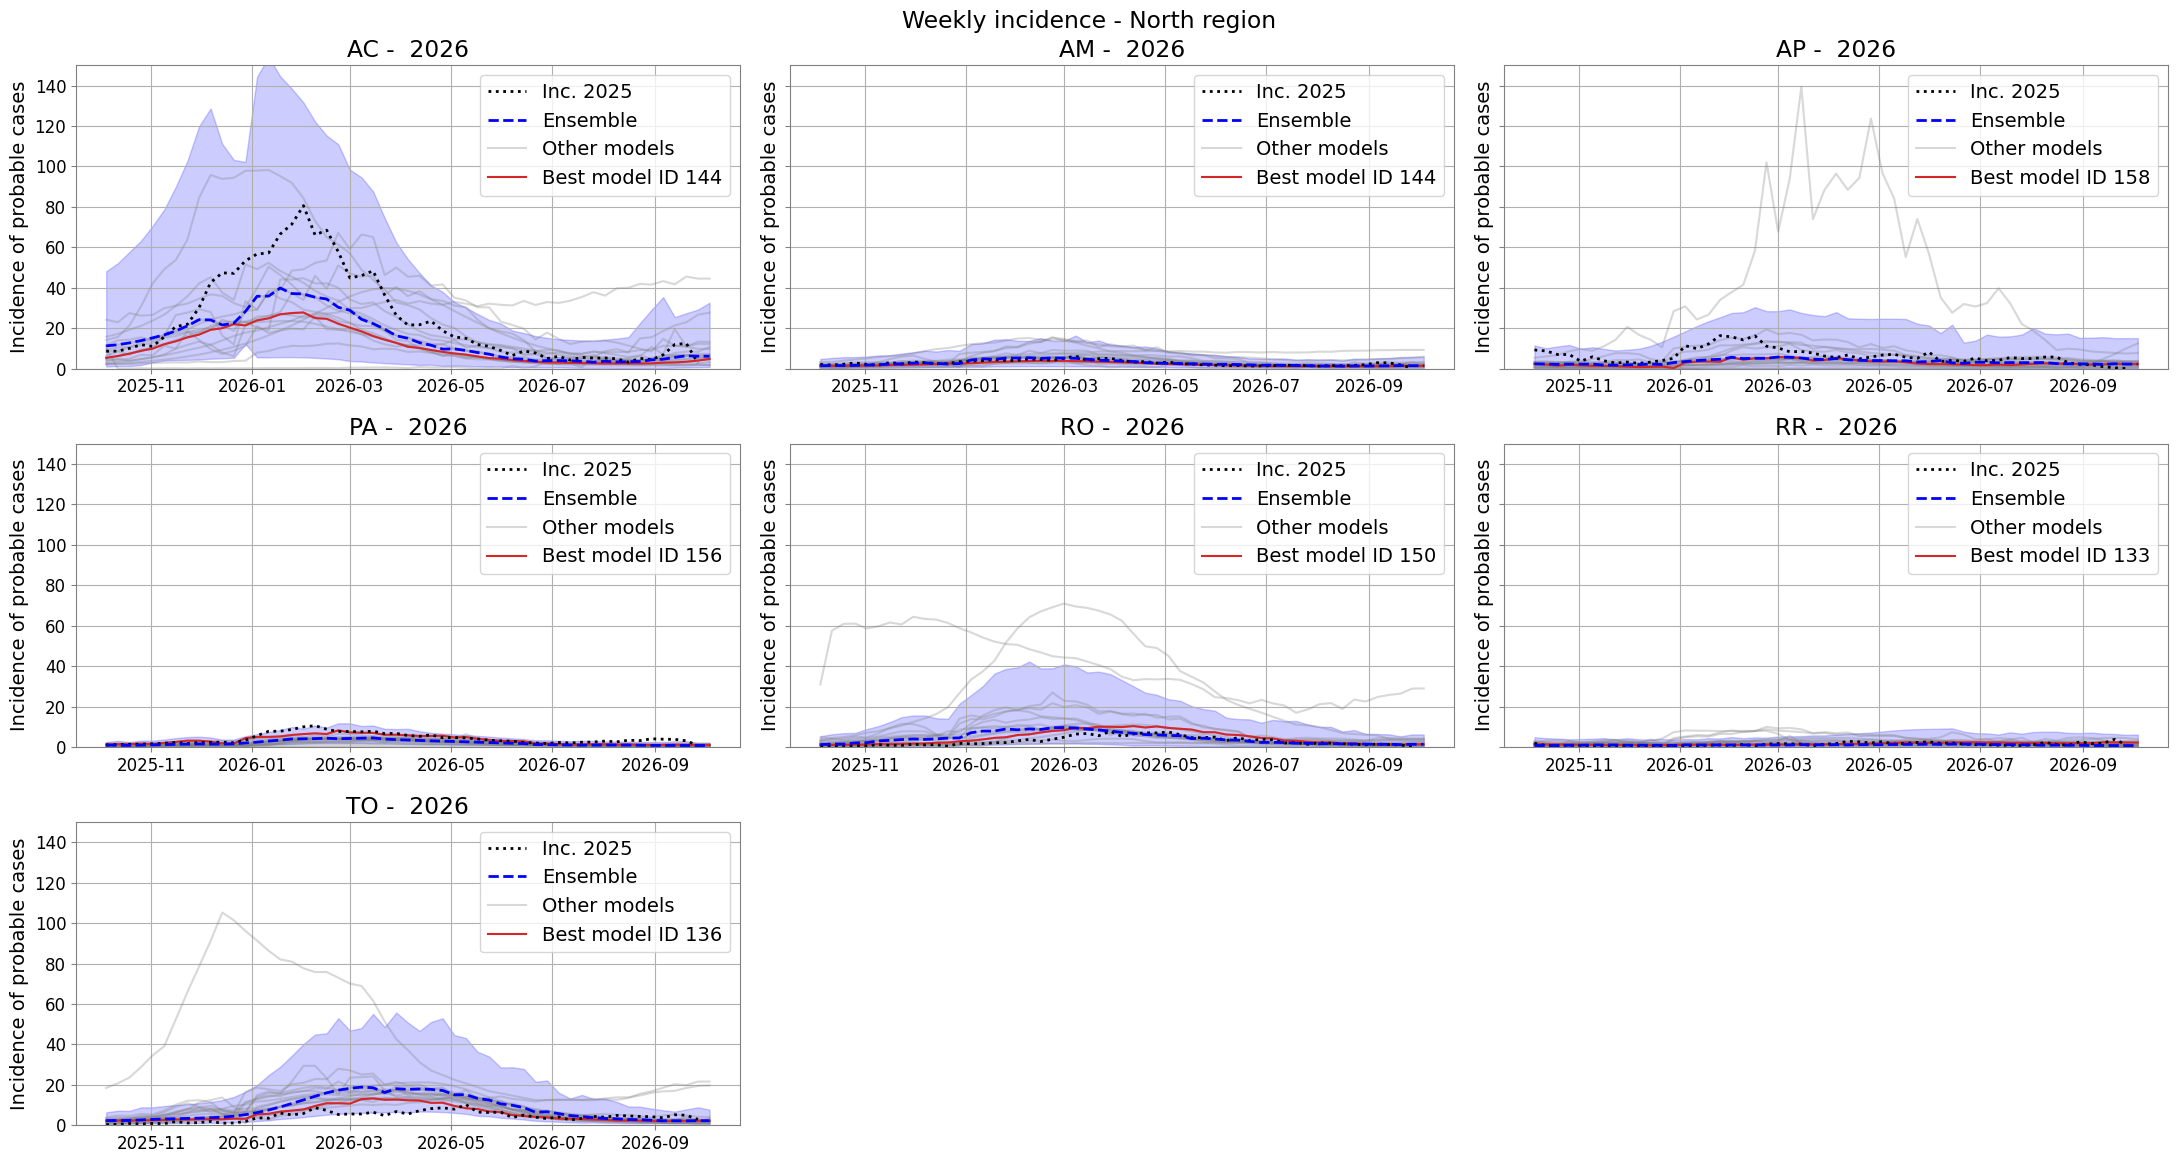

In [29]:
for language in ['pt', 'en']:

    _, ax = plt.subplots(3,3, figsize = (22, 12), sharey = True)

    for state, ax_ in zip(['AC', 'AM', 'AP', 'PA', 'RO', 'RR', 'TO'], ax.ravel()):
        
        best_model = df_bm.loc[df_bm.state == state]['best_model_norm'].values[0]
        make_comp_plot(ax_, state, best_model, df_median_ens, df_for, cumulative=False, language=language)

    ax[0,0].set_ybound([0, 150])
    ax[2,1].axis('off')
    ax[2,2].axis('off')
    
    if language == 'pt': 
        plt.suptitle('Incidência semanal - Região Norte', y = 0.97)
    else: 
        plt.suptitle('Weekly incidence - North region', y = 0.97)

    plt.tight_layout()
    plt.savefig(f'figures/weekly_cases_norte_{language}.png', dpi = 400, bbox_inches = 'tight')
    plt.show()

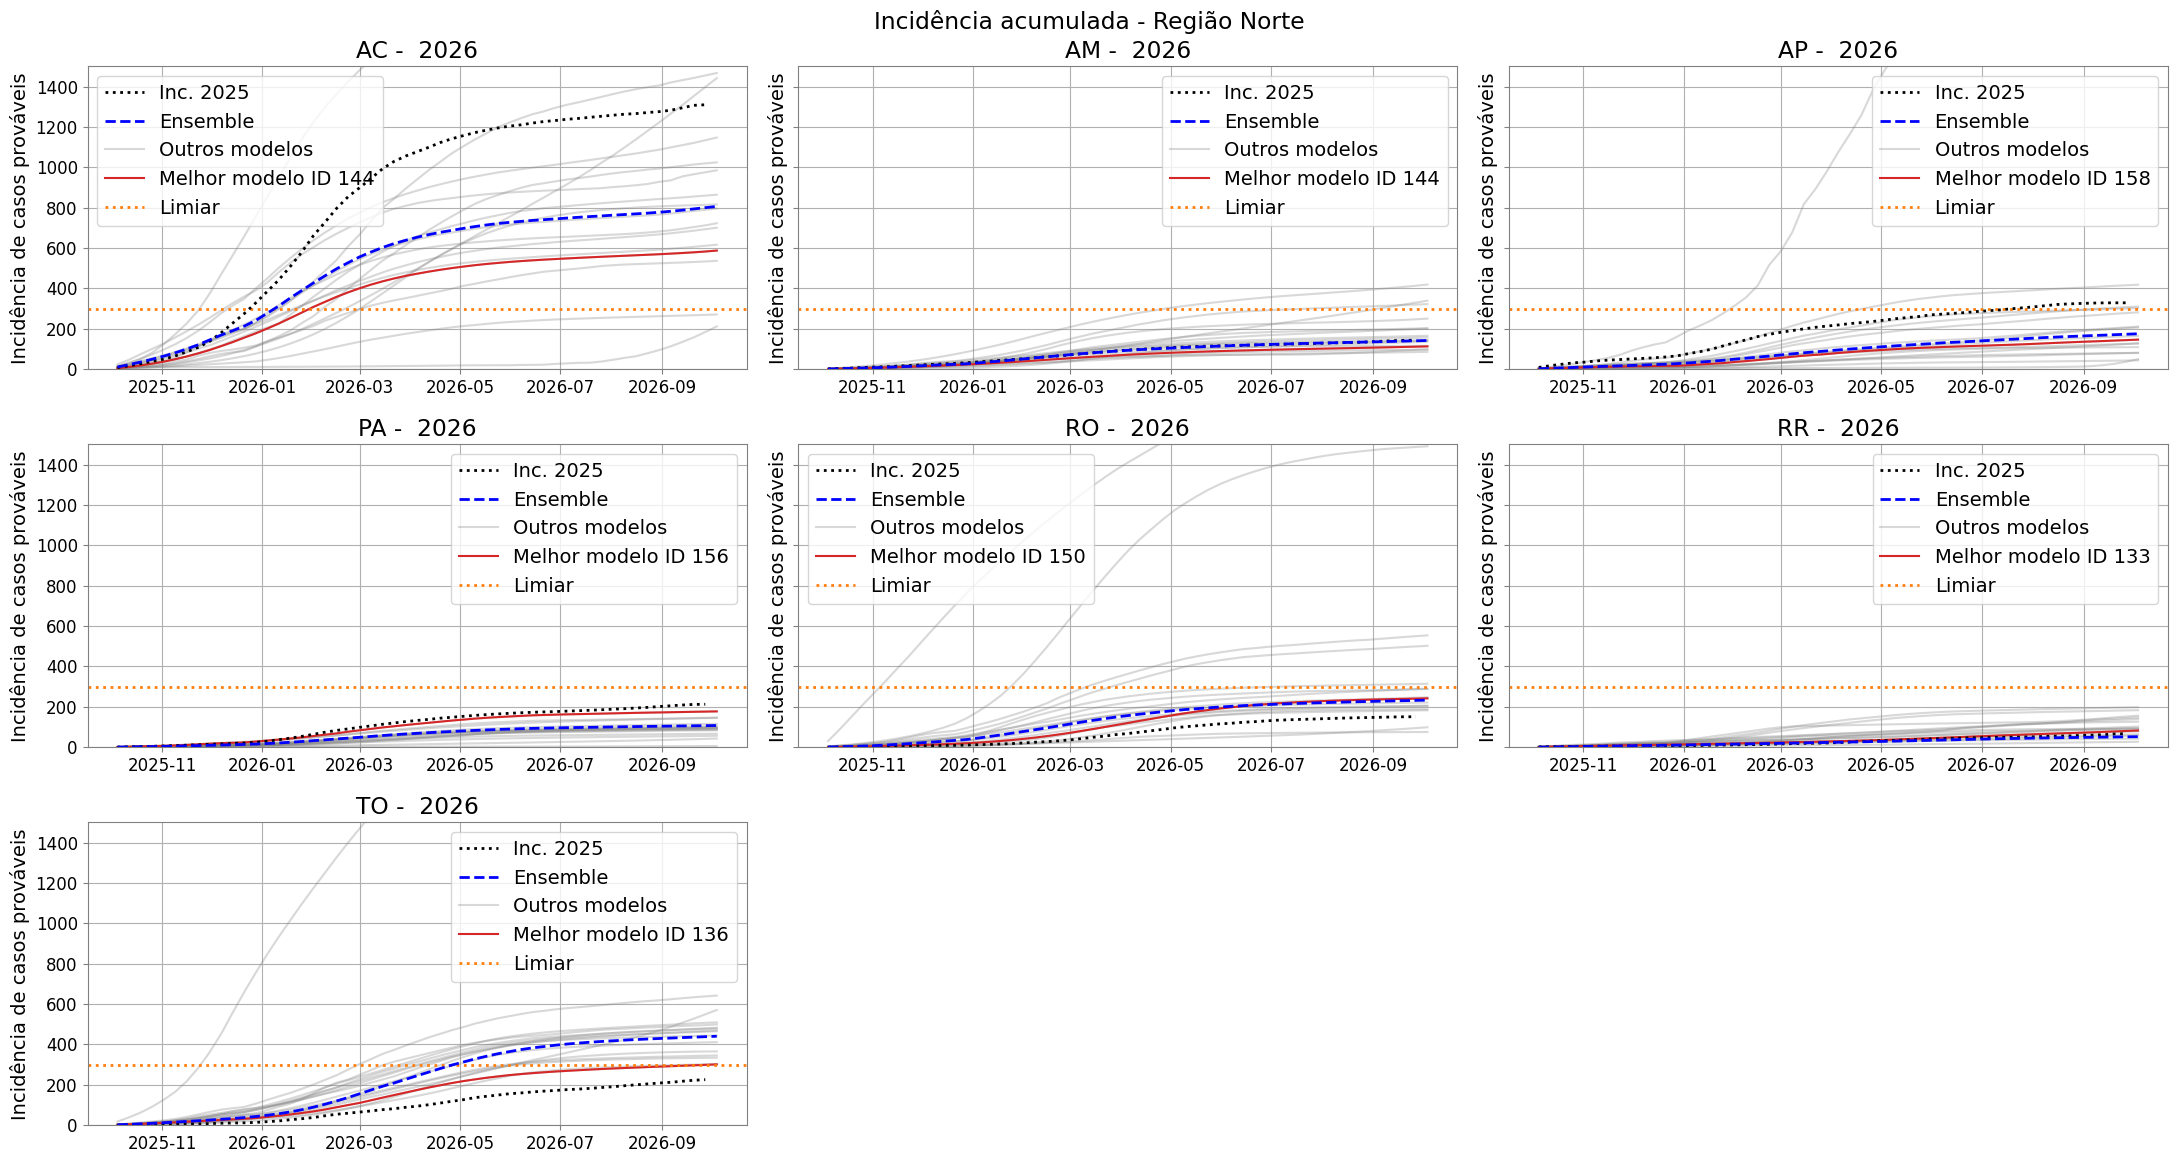

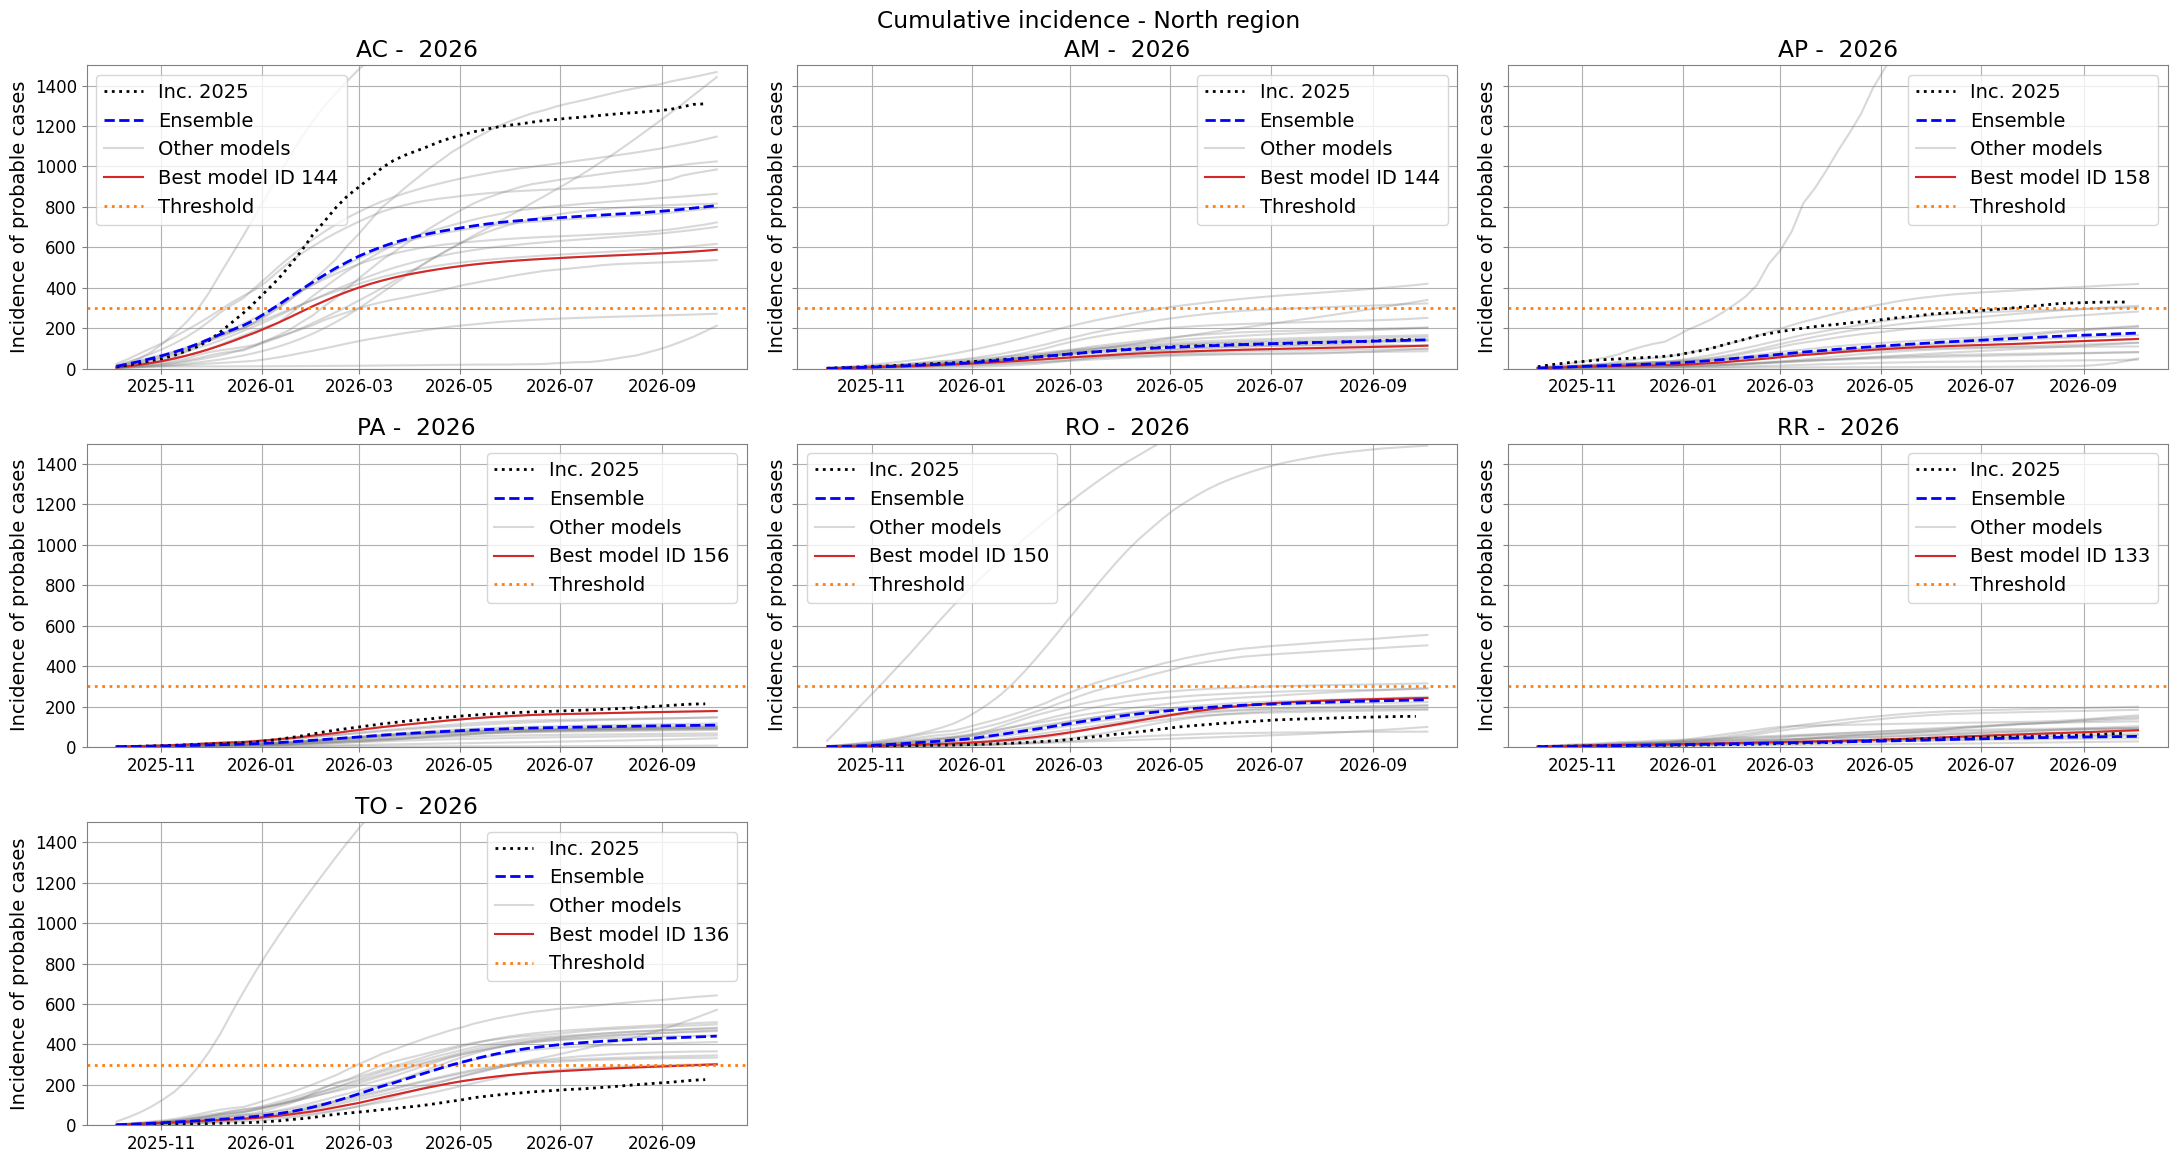

In [30]:
for language in ['pt', 'en']:

    _, ax = plt.subplots(3,3, figsize = (22, 12), sharey = True)

    for state, ax_ in zip(['AC', 'AM', 'AP', 'PA', 'RO', 'RR', 'TO'], ax.ravel()):
        
        best_model = df_bm.loc[df_bm.state == state]['best_model_norm'].values[0]
        make_comp_plot(ax_, state, best_model, df_median_ens, df_for, cumulative=True, language=language)

    ax[0,0].set_ybound([0, 1500])
    ax[2,1].axis('off')
    ax[2,2].axis('off')

    if language == 'pt': 
        plt.suptitle('Incidência acumulada - Região Norte', y = 0.97)
    else: 
        plt.suptitle('Cumulative incidence - North region', y = 0.97)
    

    plt.tight_layout()
    plt.savefig(f'figures/cumulative_cases_norte_{language}.png', dpi = 400, bbox_inches = 'tight')
    plt.show()

Gráfico dos casos acumulados por para o país:

In [31]:
df_cum_cop = pd.read_csv('predictions/ensemble_median_2026_cum_cases.csv.gz')
df_cum_cop = df_cum_cop.merge(df_pop, on = 'state')
for col in ['lower_90', 'pred', 'upper_90']:

    df_cum_cop[f'inc_{col}'] = 100000*df_cum_cop[col]/df_cum_cop['population']

df_cum_cop.head()

,state,model,lower_90,pred,upper_90,rho,population,inc_lower_90,inc_pred,inc_upper_90
0,PR,median,13770.616942,79983.896118,4.538979e+05,0.979600,11824665,116.456719,676.415747,3838.568999
1,SC,median,18322.588087,54613.057867,1.753233e+05,0.912145,8058441,227.371375,677.712449,2175.648162
2,RS,median,24064.235870,73406.115104,2.183210e+05,0.904208,11229915,214.286892,653.665812,1944.102139
3,SP,median,251444.387413,520739.987410,1.141495e+06,0.985772,45973194,546.936955,1132.703522,2482.958074
4,MG,median,83020.202900,279047.044148,8.888152e+05,0.971145,21322691,389.351433,1308.685870,4168.400699


In [32]:
order = [
    # Sul
    'PR', 'RS', 'SC',
    # Sudeste
    'ES', 'MG', 'RJ', 'SP',
    # Centro-Oeste
    'DF', 'GO', 'MT', 'MS',
    # Nordeste
    'AL', 'BA', 'CE', 'MA', 'PB', 'PE', 'PI', 'RN', 'SE',
    # Norte
    'AC', 'AM', 'AP', 'PA', 'RO', 'RR', 'TO' ]

In [33]:
df_inc = casos_2025.groupby('state')[['casprov_2025']].sum().reset_index(

).merge(df_pop, on = 'state')
df_inc['inc'] = 100000*df_inc['casprov_2025']/df_inc['population']


df_inc['state'] = pd.Categorical(df_inc['state'],
                                     categories = order,
                                     ordered = True)

df_inc = df_inc.sort_values(by = 'state')

df_inc.head()

,state,casprov_2025,population,inc
17,PR,121275.0,11824665,1025.610451
22,RS,90686.0,11229915,807.539505
23,SC,32080.0,8058441,398.091889
7,ES,50388.0,4102129,1228.337773
10,MG,182534.0,21322691,856.055176


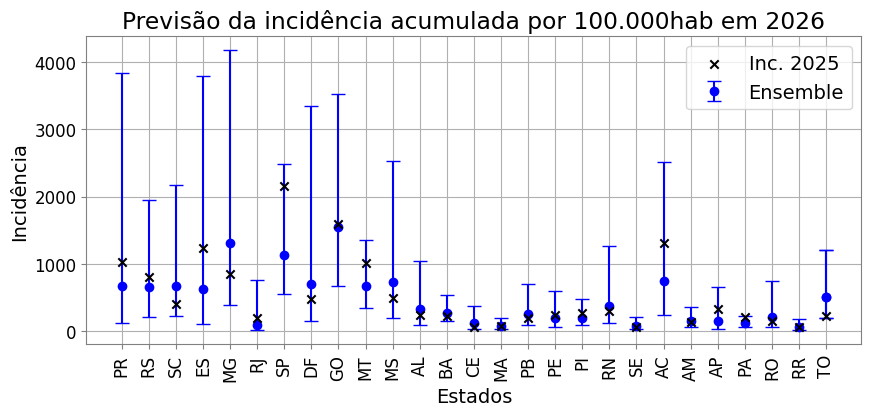

In [34]:
_, ax = plt.subplots(figsize = (10, 4))

#ax.axhline(obs, color = 'black', linewidth =2, linestyle = '--', label = 'Data')
ax.scatter(df_inc.state, df_inc.inc, marker = 'x',color = 'black', label = 'Inc. 2025', zorder = 3)
# método da cópula
x = df_cum_cop.state.astype(str)
y = df_cum_cop.inc_pred
    
# compute symmetric errors from lower and upper bounds
yerr = np.array([y - df_cum_cop.inc_lower_90, df_cum_cop.inc_upper_90 - y])

for xi, yi, yierr, low, up in zip(x, y, yerr.T, df_cum_cop.inc_lower_90, df_cum_cop.inc_upper_90):
    # condition: observed is inside prediction interval

    ax.errorbar(xi, yi, yerr=yierr.reshape(2,1), fmt="o", 
                    color='blue', ecolor='blue', capsize=5)
        
ax.errorbar(xi, yi, yerr=yierr.reshape(2,1), fmt="o", 
                    color='blue', ecolor='blue', capsize=5, label = 'Ensemble')


ax.set_ylabel('Incidência')
ax.set_xlabel('Estados')
    
ax.set_title(f'Previsão da incidência acumulada por 100.000hab em 2026')

#    ax.set_ylim([0, max(2*df_cum_cases.loc[(df_cum_cases.state == state) & (df_cum_cases.valid_test == 1)].casos.values[0],
#                        2*df_cum_cases.loc[(df_cum_cases.state == state) & (df_cum_cases.valid_test == 2)].casos.values[0], 
#                        2*df_cum_cases.loc[(df_cum_cases.state == state) & (df_cum_cases.valid_test == 3)].casos.values[0])])
#ax.set_yscale('log')
ax.grid()
ax.legend()
for label in ax.get_xticklabels():
        label.set_rotation(90)

plt.savefig('figures/ens_median_inc_2026.png', dpi = 400, bbox_inches = 'tight')